# はじめに
半年間、データ分析を学習した。学んだ技術を活かして、予測を行い、結果をまとめた。

本レポートでは、岡山市が公開する人流オープンデータを用い、エリアごとの人流動向の違いとその時系列的特徴を分析することを目的とする。中心市街地、再開発地域、住宅地、郊外商業地、地域拠点といった性格の異なるエリアによって、人流パターンに差異が生じると考えられるが、その違いを定量的に示したい。

本レポートでは、岡山市内の5地域（中心部、北長瀬、原・原尾島、岡南、西大寺）を対象に人流データを用いた分析を行い、都市機能の違いが人流動向にどのような影響を与えているのかを明らかにする。

本分析では、以下の仮説を設定した。
* 中心部は商業・業務機能の集中により、平日の滞在人口が多い。
* 岡南は郊外型商業地として、平日・休日ともに人口が安定している。
* 西大寺は周辺を住宅地が囲む特徴から、地域拠点として、中心部ほどの集中はないが安定した人流を示す。
* 原・原尾島は住宅地としての性格が強く、人流の変動が比較的小さい。
* 北長瀬は近年の再開発および商業施設の集積により、人流が増加傾向にある。

これらの仮説を検証するため、時系列分解および予測モデルを用いた分析を行う。

# 分析するデータ
## 用いたデータについて
本分析では、岡山市が公式に公開している人流データのオープンデータを使用した。データは岡山市公式ウェブサイトよりCSV形式で取得し、公開されているデータ定義および留意事項を確認した上で利用している。

## データ定義・留意点
* データは携帯端末の位置情報等をもとにした**推計値**であり、実測値ではない
* **個人を特定できないよう匿名化・集計処理**が施されている
* 特定の個人や端末の移動履歴は含まれず、地域単位での傾向把握を目的としたデータである
* 単位や集計方法（人数は概数、一定単位で丸め処理）が定義されている

## データの内容（簡潔な整理）
* **対象期間** :2018年1月 〜 2025年4月（連続した時系列データ）
* **集計頻度** :月次
* **主な項目** :
  * 人流（滞在人口・通行人口の推計値）
  * 属性別集計（性別、年代）
  * 平日／祝休日別集計
* **データ形式** :CSV形式（時系列データ）
* **対象エリア** :
  * 中心市街地
  * 岡南
  * 西大寺
  * 浜・原尾島
  * 北長瀬
  
これらのエリアはいずれも岡山市の都心部またはその周辺に位置しており、商業拠点、交通結節点、住宅地など異なる機能を持つ地域である。そのため、人流の時間的変化や季節性に地域差が表れやすいと考えられる。


# 実行環境
* パソコン :Surface Pro 7
* 開発環境 :Google Coraboratory
* 言語 :Python
* ライブラリ :Matplotlib、prophet、plotly、pandas、numpy、seaborn

# 分析の過程
## 前処理について
2018年1月～2025年4月までのデータを平日と休日にそれぞれ分けて分析。各世代動向の推移を `Seaborn` の `lineplot` を使ってカテゴリ別の時系列折れ線グラフを描画。
* `pandas`  が扱える日時型 `datetime` に変換
* `center_weekday_df` 平日と `center_holiday_df` 休日のDataFrameを作成
* `melt` メソッドで縦持ちに変更
* `ds` `Category` `Value` カラムにまとめ直し

予測で使用する `decompose` `Prophet` に適用させるため、`center_weekday_df` 平日と `center_holiday_df` 休日の前処理を実行。
* dsカラムとyに変換
* yは男性と女性を足した新しいカラムに変換

## 予測について
本分析では、時系列データの構造を把握するために `decompose` を用いてトレンド・季節性・残差を分解。さらに、将来の傾向を予測するために、季節性を考慮した柔軟な予測が可能な `Prophet` を採用した。

# 各地域の分析

## 必要なライブラリをimport

In [163]:
!pip install matplotlib
!pip install matplotlib seaborn

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
!pip install japanize-matplotlib

In [166]:
import japanize_matplotlib

In [167]:
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

## 中心市街地の分析
岡山駅周辺部のデータ 'area1_month.csv' を基に、過去の傾向と将来予測を分析。

### `center_df` の前処理

In [168]:

# center_df の前処理
center_df = pd.read_csv('area1_month.csv', encoding="cp932", header=1)
center_df.head()

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,...,NaN,祝休日,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018年2月,期間全体,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,...,NaN,祝休日,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018年3月,期間全体,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,...,NaN,祝休日,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018年4月,期間全体,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,...,NaN,祝休日,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018年5月,期間全体,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,...,NaN,祝休日,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


In [169]:
center_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [170]:
center_df = center_df.rename(columns={'Unnamed: 0': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
center_df['ds'] = center_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
center_df['ds'] = pd.to_datetime(center_df['ds'])

# 不要な列を削除
columns_to_drop = [
    'Unnamed: 1',
    '男性',
    '女性',
    '20代',
    '30代',
    '40代',
    '50代',
    '60代',
    '70歳以上',
    'Unnamed: 10',
    'Unnamed: 20',
    'Unnamed: 21']


# columns_to_drop というリストに指定されている列のうち、center_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを center_df に格納
center_df = center_df.drop(columns=[col for col in columns_to_drop if col in center_df.columns])

center_df.head()

,ds,Unnamed: 11,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,平日,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-02-01,平日,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-03-01,平日,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-04-01,平日,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-05-01,平日,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


### 中心市街地の滞在人口推移
`center_weekday_df` と `center_holiday_df` のそれぞれ推移を比較

#### `center_weekday_df` 平日の場合


In [171]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

# 平日用のDataFrameを作成
center_weekday_df = center_df[['ds'] + demographic_columns].copy()

#meltメソッドで縦持ちに変更
#ds以外は 'Category' とその値を含む 'Value' カラムにまとめ直し
center_weekday_melted = center_weekday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')

#'DayType'カラムを追加して、すべてのロウにweekdayを格納
#pd.to_numeric() 関数で文字列を数値に変換
center_weekday_melted['DayType'] = 'weekday'
center_weekday_melted['Value'] = pd.to_numeric(center_weekday_melted['Value'])
center_weekday_melted.head()

,ds,Category,Value,DayType
0,2018-01-01,男性.1,1791.2,weekday
1,2018-02-01,男性.1,1626.6,weekday
2,2018-03-01,男性.1,1903.0,weekday
3,2018-04-01,男性.1,1764.6,weekday
4,2018-05-01,男性.1,1835.4,weekday


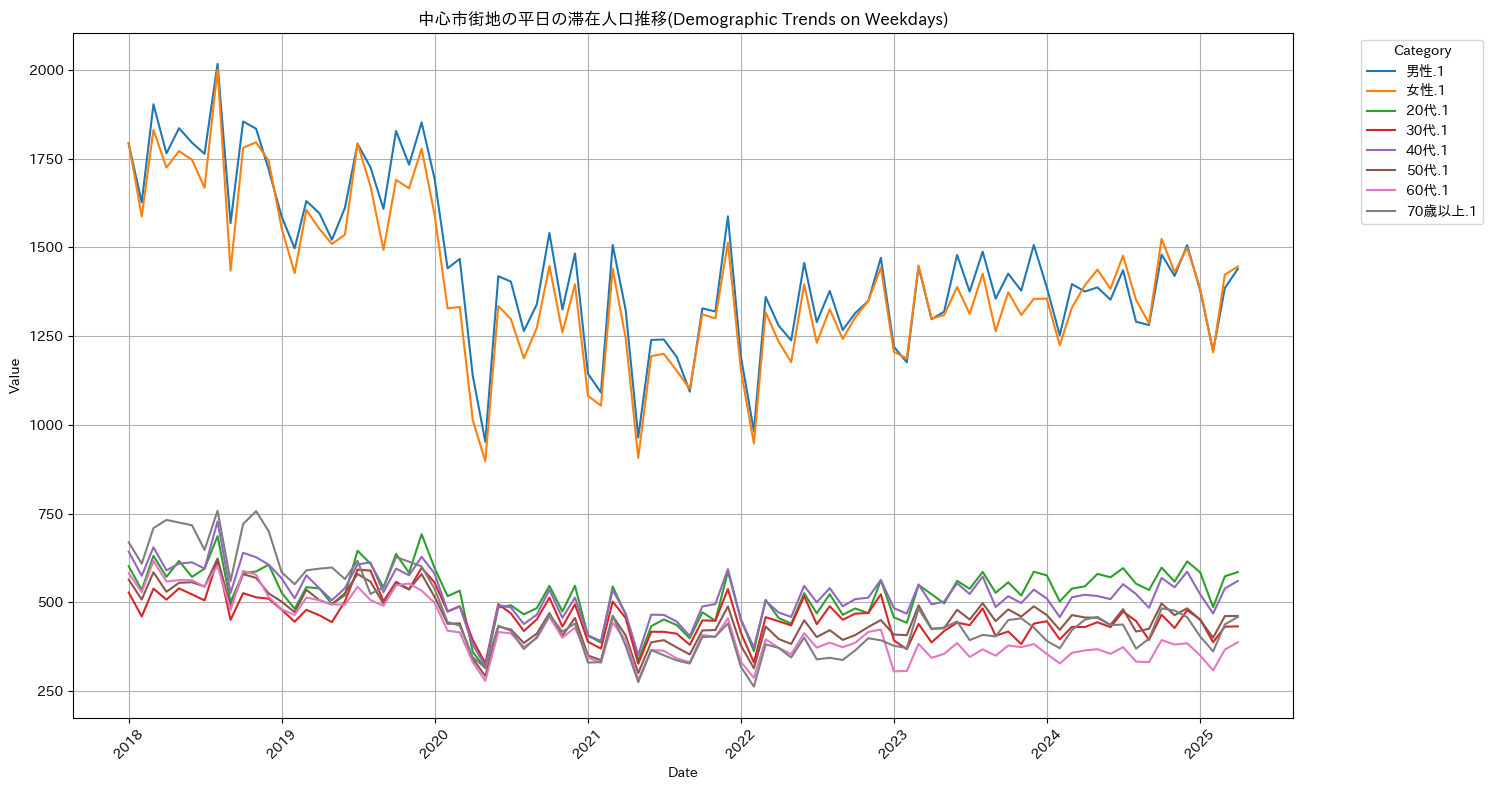

In [172]:

#グラフの描写
plt.figure(figsize=(15, 8))
sns.lineplot(data=center_weekday_melted, x='ds', y='Value', hue='Category')
plt.title('中心市街地の平日の滞在人口推移(Demographic Trends on Weekdays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### `center_holiday_df` 休日の場合

In [173]:
from numpy._core.defchararray import center
# 中心市街地の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性.1', '女性.1', ...]）のサフィックスを.1から.2に変更して、
# 休日のデータに対応するカラム名を作成します。
center_holiday_demographic_columns = [col.replace('.1', '.2') for col in demographic_columns]
center_holiday_demographic_columns

['男性.2', '女性.2', '20代.2', '30代.2', '40代.2', '50代.2', '60代.2', '70歳以上.2']

In [174]:
# center_dfからからdsカラムと、center_holiday_demographic_columnsを抽出
# 新しいdfを作成
center_holiday_df = center_df[['ds'] + center_holiday_demographic_columns].copy()

#平日と同様に、縦持ち形式（melt）に変換
center_holiday_melted = center_holiday_df.melt(id_vars=['ds'], var_name='Category', value_name='Value')
center_holiday_melted['DAyType'] = 'Holiday'

# center_holiday_meltedのCategoryカラムから.1サフィックスを削除して、表示名を元のカテゴリ名に戻します。
center_holiday_melted['Category'] = center_holiday_melted['Category'].str.replace('.1', '', regex=False)
center_holiday_melted['Value'] = pd.to_numeric(center_holiday_melted['Value'])
center_holiday_melted

,ds,Category,Value,DAyType
0,2018-01-01,男性.2,741.6,Holiday
1,2018-02-01,男性.2,705.0,Holiday
2,2018-03-01,男性.2,832.1,Holiday
3,2018-04-01,男性.2,834.9,Holiday
4,2018-05-01,男性.2,846.1,Holiday
...,...,...,...,...
699,2024-12-01,70歳以上.2,167.9,Holiday
700,2025-01-01,70歳以上.2,169.5,Holiday
701,2025-02-01,70歳以上.2,178.8,Holiday
702,2025-03-01,70歳以上.2,208.0,Holiday


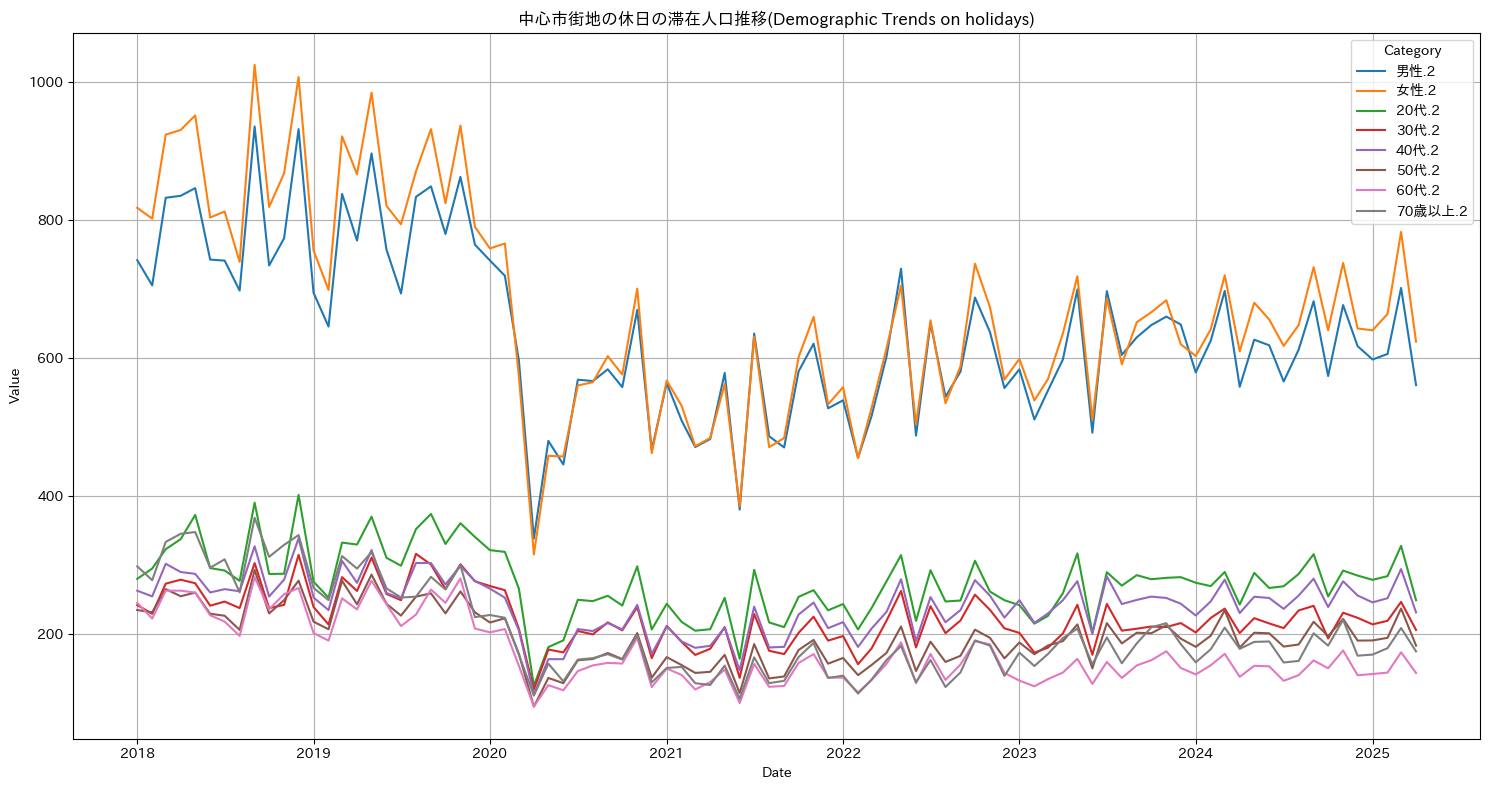

In [175]:
#中心市街地の休日滞在人口の推移を折れ線グラフでプロット
#center_holiday_meltedデータフレームを使用
plt.figure(figsize=(15, 8))
sns.lineplot(data=center_holiday_melted, x='ds', y='Value', hue='Category')
plt.title('中心市街地の休日の滞在人口推移(Demographic Trends on holidays)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### 予測結果①

### 中心市街地の季節性、トレンド分析


#### `center_weekday_df` 平日の場合

In [176]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
center_weekday_df['y'] = center_weekday_df['男性.1'] + center_weekday_df['女性.1']
center_weekday_df.head()

,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,1791.2,1794.1,601.4,527.6,642.2,563.7,581.6,668.8,3585.3
1,2018-02-01,1626.6,1586.9,534.6,460.0,574.5,507.7,528.1,608.6,3213.5
2,2018-03-01,1903.0,1830.7,630.8,538.3,654.8,584.4,616.5,708.9,3733.7
3,2018-04-01,1764.6,1724.6,571.7,507.4,590.0,529.6,558.5,732.1,3489.2
4,2018-05-01,1835.4,1771.0,616.5,539.1,608.9,554.8,562.4,724.6,3606.4


In [177]:

weekady_result = seasonal_decompose(
    center_weekday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

weekady_trend = weekady_result.trend
weekady_seasonal = weekady_result.seasonal
weekady_resid = weekady_result.resid

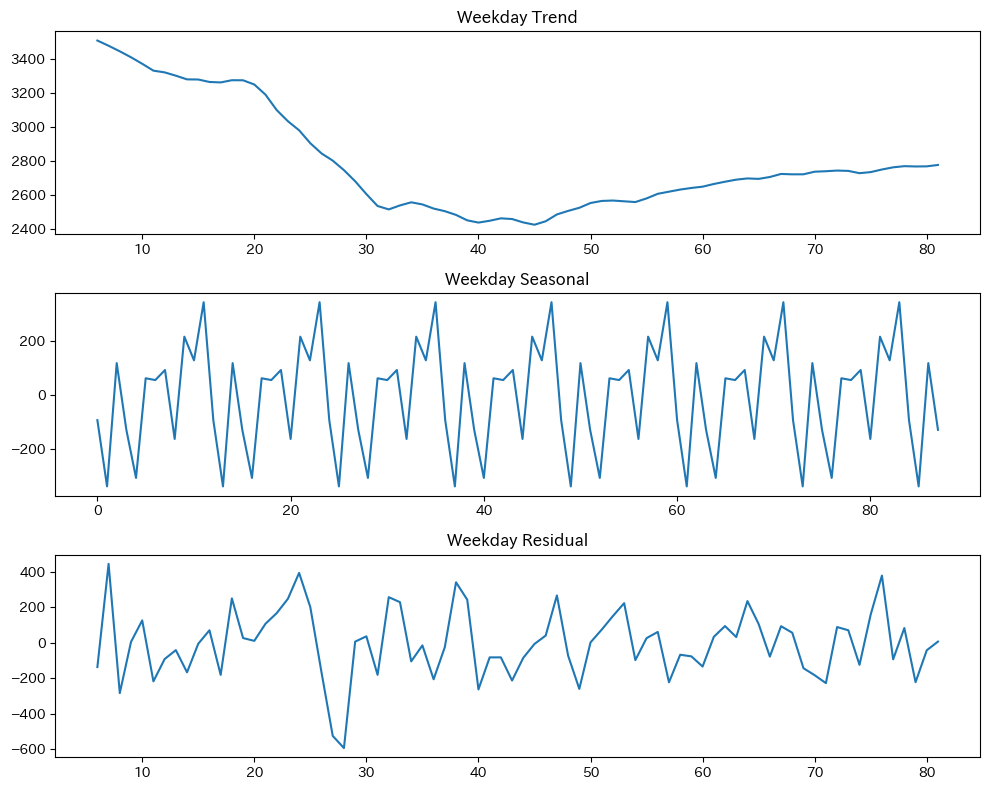

In [178]:


fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(weekady_trend)
axes[0].set_title('Weekday Trend')

# 季節成分のプロット
axes[1].plot(weekady_seasonal)
axes[1].set_title('Weekday Seasonal')

# 残差成分のプロット
axes[2].plot(weekady_resid)
axes[2].set_title('Weekday Residual')

plt.tight_layout()
plt.show()

* 中心市街地の平日滞在人口が減少傾向を辿っていたが、緩やかに回復傾向にある。
* 特定の月に対応するピークと谷を持つ明確な年間季節性が見られえる。
* 特定の月だけ大きくマイナスがあり、緊急事態宣言の影響を強く受けている。

#### `center_holiday_df` 休日の場合

In [179]:
center_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018-02-01,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018-03-01,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018-04-01,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018-05-01,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


In [180]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
center_holiday_df['y'] = center_holiday_df['男性.2'] + center_holiday_df['女性.2']
center_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5,1559.1
1,2018-02-01,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4,1506.8
2,2018-03-01,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9,1755.7
3,2018-04-01,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7,1765.3
4,2018-05-01,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2,1797.6


In [181]:

holiday_result = seasonal_decompose(
    center_holiday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

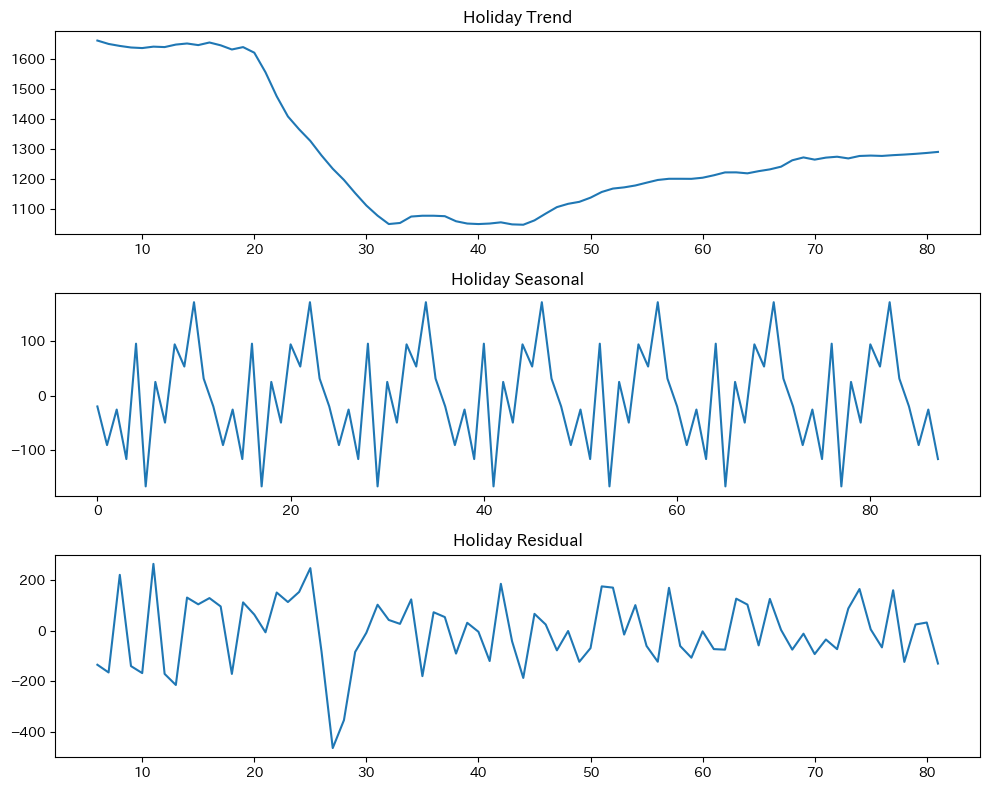

In [182]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(holiday_trend)
axes[0].set_title('Holiday Trend')

# 季節成分のプロット
axes[1].plot(holiday_seasonal)
axes[1].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[2].plot(holiday_resid)
axes[2].set_title('Holiday Residual')

plt.tight_layout()
plt.show()



* 平日に比べて、コロナ禍で急激に減少が進んでいる。平日と同様に、長期的には中心市街地の平日滞在人口が緩やかに回復傾向にある。
* 平日同様に、特定の月に対応するピークと谷を持つ明確な年間季節性が見られえる。
* 特定の月だけ大きくマイナスがあり、緊急事態宣言の影響を強く受けている

### 予測結果②

### 中心市街地のProphetモデル

In [183]:
#Prophetクラスをインスタンス化
weekday_model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `center_weekday_forecast` 平日の場合

In [184]:
#学習期間を2024年4月まで
weekday_model.fit(center_weekday_df[center_weekday_df['ds'] <= '2024-04-01'])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [185]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_weekday_future = weekday_model.make_future_dataframe(periods=12, freq='MS')


In [186]:
#予測を実行
center_weekday_forecast = weekday_model.predict(center_weekday_future)

#出力された予測値や、不確実性区間を確認
center_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,3515.100826,3300.998578,3706.747972
1,2018-02-01,3247.822315,3070.014875,3457.658216
2,2018-03-01,3757.858889,3569.103715,3973.887160
3,2018-04-01,3450.093855,3250.378131,3650.002035
4,2018-05-01,3245.173877,3044.442777,3459.089579
...,...,...,...,...
83,2024-12-01,3176.340455,2960.293839,3385.564605
84,2025-01-01,2500.274661,2306.369059,2681.680106
85,2025-02-01,2428.308211,2222.170660,2632.069703
86,2025-03-01,2916.459772,2704.393718,3127.755571


Text(0.5, 1.0, 'Center Weekday Forecast')

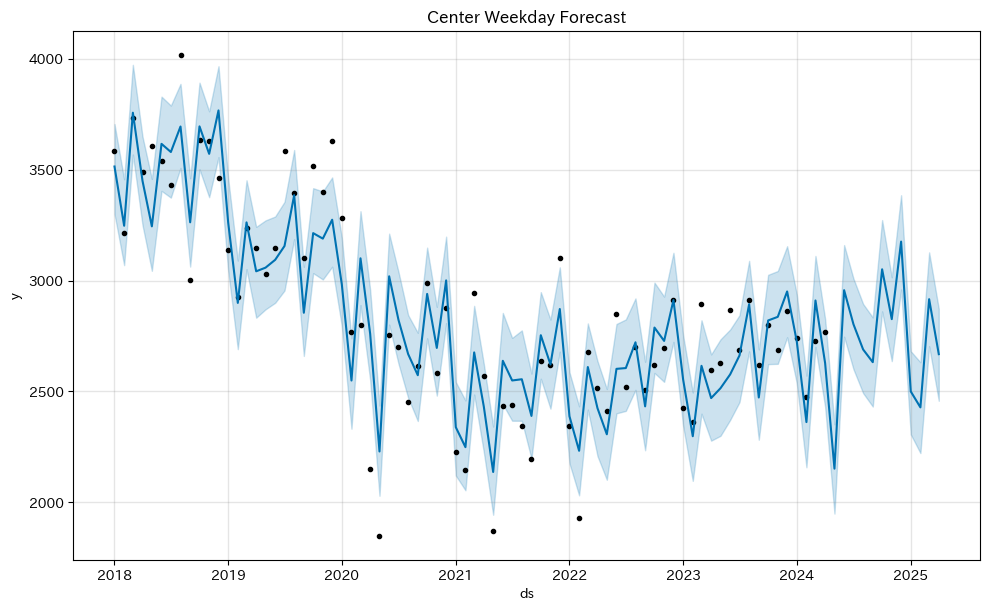

In [187]:
#グラフ上に可視化
fig_forecast = weekday_model.plot(center_weekday_forecast)
plt.title('Center Weekday Forecast')


In [188]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = center_weekday_forecast[(center_weekday_forecast['ds'] >= start_date) & (center_weekday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,2151.826286,1949.087386,2351.946106
77,2024-06-01,2957.056224,2747.086039,3160.653357
78,2024-07-01,2803.422844,2600.565433,3009.539596
79,2024-08-01,2689.678121,2492.830643,2895.014012
80,2024-09-01,2632.276822,2432.038428,2834.235937
81,2024-10-01,3051.309477,2861.445998,3273.657225
82,2024-11-01,2826.484328,2636.960347,3015.503607
83,2024-12-01,3176.340455,2960.293839,3385.564605
84,2025-01-01,2500.274661,2306.369059,2681.680106
85,2025-02-01,2428.308211,2222.170660,2632.069703


In [189]:
# 予測の実施（全期間）
center_weekday_df_future = weekday_model.make_future_dataframe(periods=12,
                                    freq='M')
center_weekday_df_pred = weekday_model.predict(center_weekday_df_future)

# 元のデータセットに予測値を結合
center_weekday_df['Predict'] = center_weekday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [190]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = center_weekday_df.iloc[:-12].loc[:, 'Predict']
test_pred = center_weekday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = center_weekday_df.iloc[:-12].loc[:, 'y']
y_test = center_weekday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
196.07383178806555
MAE:
157.8513519106247
MAPE:
0.056599264794956666


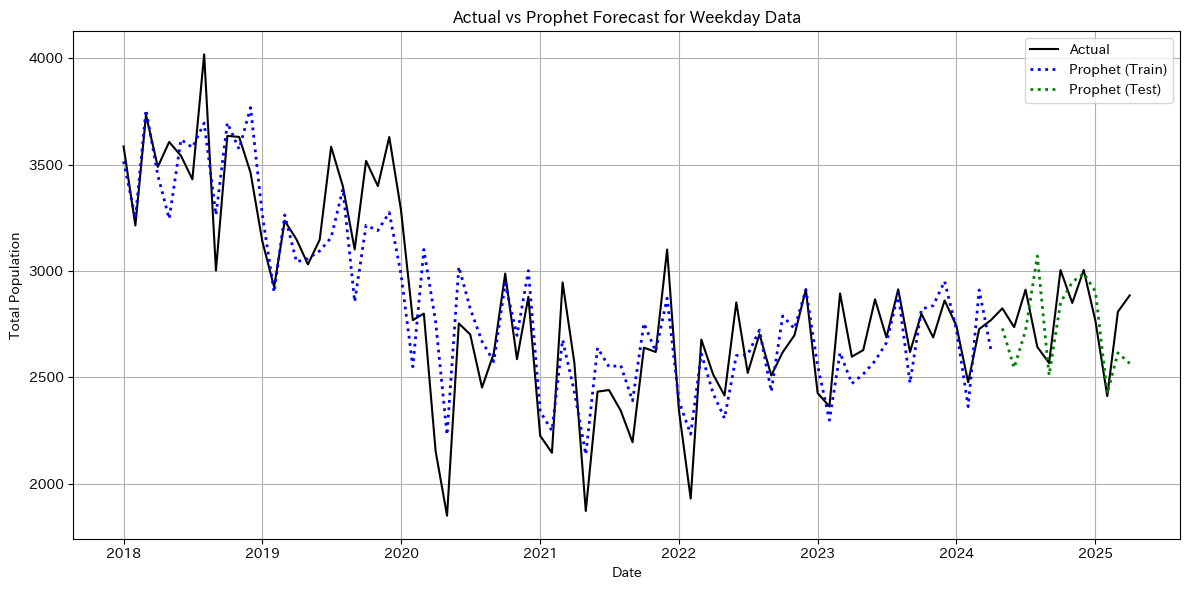

In [191]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(center_weekday_df['ds'], center_weekday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(center_weekday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(center_weekday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Weekday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 平日の「Actual」と「Predicted」の線は比較的近い位置にあり、モデルが過去のトレンドや季節性をうまく捉えていることが視覚的にも確認できる。特に、予測期間（2024年5月以降）も、実績値のパターンを概ね踏襲しているように見える。

#### `center_holiday_forecast` 休日の場合

In [192]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)

#学習期間を2024年4月まで
holiday_model.fit(center_holiday_df[center_holiday_df['ds'] <= '2024-04-01'])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [193]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [194]:
#予測を実行
center_holiday_forecast = holiday_model.predict(center_holiday_future)

#出力された予測値や、不確実性区間を確認
center_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,1709.730233,1538.896016,1878.832972
1,2018-02-01,1622.328150,1454.629232,1796.526705
2,2018-03-01,1695.939299,1520.897350,1856.112397
3,2018-04-01,1629.724263,1461.384917,1782.806737
4,2018-05-01,1836.548440,1675.073127,1993.715085
...,...,...,...,...
83,2024-12-01,1173.350698,1001.118354,1355.057323
84,2025-01-01,1247.890162,1095.853810,1421.524612
85,2025-02-01,1207.146121,1034.913737,1360.915667
86,2025-03-01,1297.322712,1128.695220,1482.851737


Text(0.5, 1.0, 'Center Holiday Forecast')

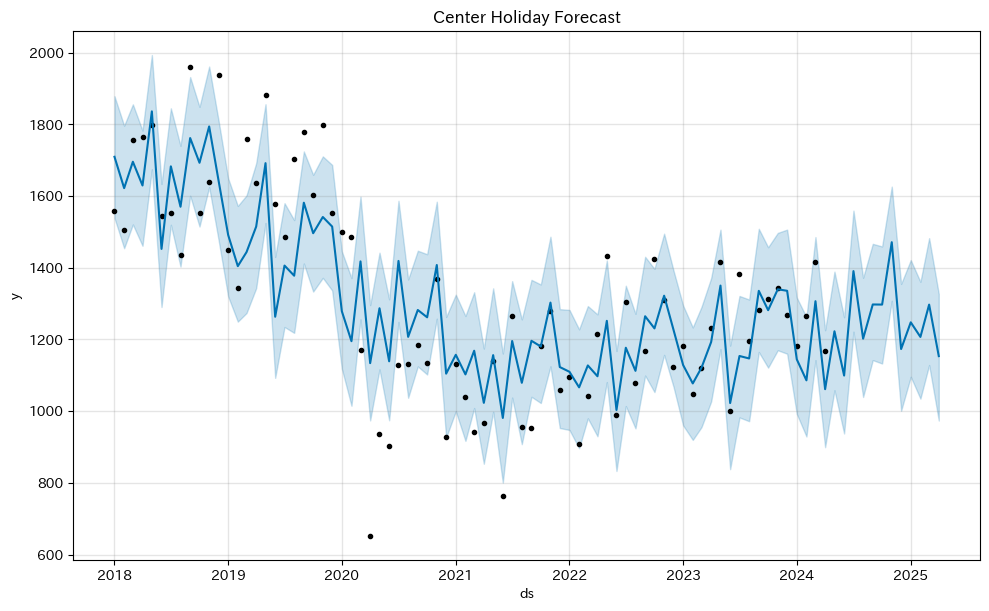

In [195]:
#グラフ上に可視化
fig_forecast = holiday_model.plot(center_holiday_forecast)
plt.title('Center Holiday Forecast')


In [196]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = center_holiday_forecast[(center_holiday_forecast['ds'] >= start_date) & (center_holiday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,1222.918646,1058.461296,1389.309265
77,2024-06-01,1099.365042,937.664905,1261.985224
78,2024-07-01,1390.803539,1221.832438,1559.563350
79,2024-08-01,1202.215104,1039.505270,1372.118918
80,2024-09-01,1297.675665,1142.391766,1466.908509
81,2024-10-01,1297.384346,1132.911623,1459.632160
82,2024-11-01,1471.429840,1307.815150,1626.574242
83,2024-12-01,1173.350698,1001.118354,1355.057323
84,2025-01-01,1247.890162,1095.853810,1421.524612
85,2025-02-01,1207.146121,1034.913737,1360.915667


In [197]:
# 予測の実施（全期間）
center_holiday_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
center_holiday_df_pred = holiday_model.predict(center_holiday_df_future)
# 元のデータセットに予測値を結合
center_holiday_df['Predict'] = center_holiday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [198]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = center_holiday_df.iloc[:-12].loc[:, 'Predict']
test_pred = center_holiday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = center_holiday_df.iloc[:-12].loc[:, 'y']
y_test = center_holiday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
174.8602475996976
MAE:
144.57392638875697
MAPE:
0.11150100573666273


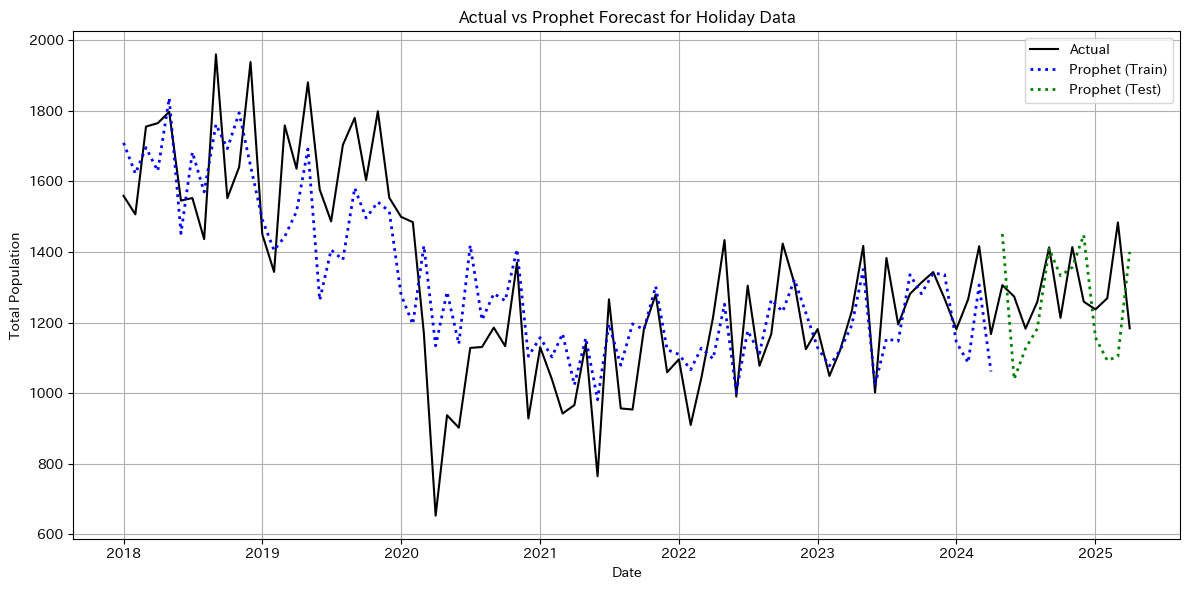

In [199]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(center_holiday_df['ds'], center_holiday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(center_holiday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(center_holiday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 休日の予測はMAPEが11.15%と平日の5.66%よりもやや誤差が大きいことがわかる。休日の人流が平日と比較してより変動しやすく、予測が難しい可能性が考えられる。
* 休日の「Actual」と「Predicted」の線は、平日と比較して乖離が見られる箇所がある。特に、大きな変動があった時期（例えば、パンデミック初期）において、予測が実績に追従しきれていない様子がうかがえる。

## 岡南地域の分析
岡南地域のデータ 'kounan_month.csv' を基に、過去の傾向と将来予測を分析。

### `kounan_df` の前処理

In [200]:


# kounan_df の前処理
kounan_df = pd.read_csv('kounan_month.csv', encoding="cp932", header=1)
kounan_df.head()

,岡南,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,468.1,481.3,126.2,132.7,185.2,151.4,199.8,154.2,...,NaN,祝休日,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4
1,2018年2月,期間全体,430.7,444.4,116.8,120.7,161.2,142.9,188.2,145.3,...,NaN,祝休日,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5
2,2018年3月,期間全体,477.4,516.8,129.5,148.0,197.3,162.9,202.7,153.7,...,NaN,祝休日,162.8,176.7,43.0,55.8,67.8,56.1,69.1,47.6
3,2018年4月,期間全体,475.7,583.3,142.8,148.2,176.1,160.6,196.5,234.6,...,NaN,祝休日,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7
4,2018年5月,期間全体,484.0,553.0,134.3,146.0,174.8,164.1,209.8,208.1,...,NaN,祝休日,164.8,190.7,49.3,50.9,61.8,56.0,66.8,70.7


In [201]:
kounan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   岡南           88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [202]:
kounan_df = kounan_df.rename(columns={'岡南': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
kounan_df['ds'] = kounan_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
kounan_df['ds'] = pd.to_datetime(kounan_df['ds'])

# 不要な列を削除
columns_to_drop = [
    'Unnamed: 1',
    '男性',
    '女性',
    '20代',
    '30代',
    '40代',
    '50代',
    '60代',
    '70歳以上',
    'Unnamed: 10',
    'Unnamed: 20',
    'Unnamed: 21']


# columns_to_drop というリストに指定されている列のうち、kounan_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを kounan_df に格納
kounan_df = kounan_df.drop(columns=[col for col in columns_to_drop if col in kounan_df.columns])

kounan_df.head()

,ds,Unnamed: 11,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,平日,318.2,321.0,85.3,86.4,123.0,99.5,134.4,110.8,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4
1,2018-02-01,平日,289.9,303.5,80.7,76.6,106.9,95.6,126.8,106.8,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5
2,2018-03-01,平日,314.6,340.1,86.5,92.2,129.5,106.8,133.5,106.2,162.8,176.7,43.0,55.8,67.8,56.1,69.1,47.6
3,2018-04-01,平日,306.1,367.1,90.9,88.7,110.8,103.0,129.7,150.0,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7
4,2018-05-01,平日,319.2,362.3,84.9,95.1,113.1,108.0,143.0,137.4,164.8,190.7,49.3,50.9,61.8,56.0,66.8,70.7


In [203]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

# 平日用のDataFrameを作成
kounan_weekday_df = kounan_df[['ds'] + demographic_columns].copy()


### 予測結果①

### 岡南地域の季節性、トレンド分析


#### `kounan_weekday_df` 平日の場合

In [204]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
kounan_weekday_df['y'] = kounan_weekday_df['男性.1'] + kounan_weekday_df['女性.1']
kounan_weekday_df.head()


,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,318.2,321.0,85.3,86.4,123.0,99.5,134.4,110.8,639.2
1,2018-02-01,289.9,303.5,80.7,76.6,106.9,95.6,126.8,106.8,593.4
2,2018-03-01,314.6,340.1,86.5,92.2,129.5,106.8,133.5,106.2,654.7
3,2018-04-01,306.1,367.1,90.9,88.7,110.8,103.0,129.7,150.0,673.2
4,2018-05-01,319.2,362.3,84.9,95.1,113.1,108.0,143.0,137.4,681.5


In [205]:

weekady_result = seasonal_decompose(
    kounan_weekday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

weekady_trend = weekady_result.trend
weekady_seasonal = weekady_result.seasonal
weekady_resid = weekady_result.resid

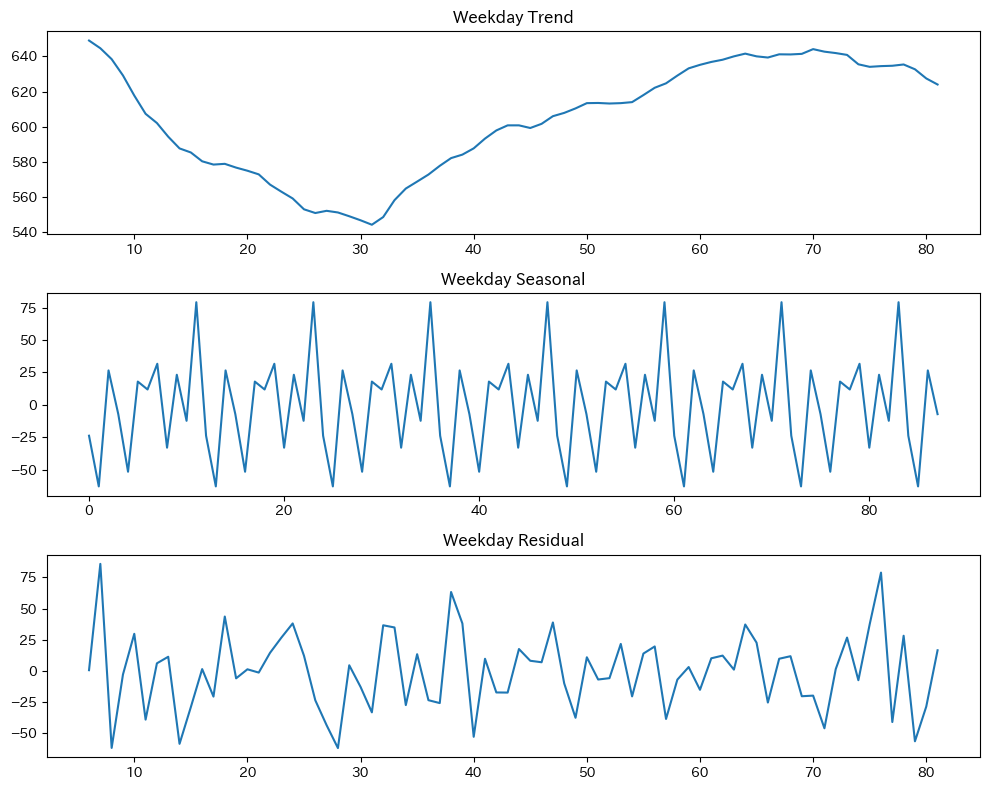

In [206]:


fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(weekady_trend)
axes[0].set_title('Weekday Trend')

# 季節成分のプロット
axes[1].plot(weekady_seasonal)
axes[1].set_title('Weekday Seasonal')

# 残差成分のプロット
axes[2].plot(weekady_resid)
axes[2].set_title('Weekday Residual')

plt.tight_layout()
plt.show()

* トレンドについて、過去には緩やかな上昇傾向が見られたが、直近では横ばい、あるいはごくわずかな下降傾向にあるように見える。


#### `kounan_holiday_df` 休日の場合

In [207]:
from numpy._core.defchararray import center
# 岡南地域の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性.1', '女性.1', ...]）のサフィックスを.1から.2に変更して、
# 休日のデータに対応するカラム名を作成します。
kounan_holiday_demographic_columns = [col.replace('.1', '.2') for col in demographic_columns]
kounan_holiday_demographic_columns


['男性.2', '女性.2', '20代.2', '30代.2', '40代.2', '50代.2', '60代.2', '70歳以上.2']

In [208]:
# kounan_dfからからdsカラムと、kounan_holiday_demographic_columnsを抽出
# 新しいdfを作成
kounan_holiday_df = kounan_df[['ds'] + kounan_holiday_demographic_columns].copy()


In [209]:
kounan_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4
1,2018-02-01,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5
2,2018-03-01,162.8,176.7,43.0,55.8,67.8,56.1,69.1,47.6
3,2018-04-01,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7
4,2018-05-01,164.8,190.7,49.3,50.9,61.8,56.0,66.8,70.7


In [210]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
kounan_holiday_df['y'] = kounan_holiday_df['男性.2'] + kounan_holiday_df['女性.2']
kounan_holiday_df.head()


,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4,310.2
1,2018-02-01,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5,281.7
2,2018-03-01,162.8,176.7,43.0,55.8,67.8,56.1,69.1,47.6,339.5
3,2018-04-01,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7,385.8
4,2018-05-01,164.8,190.7,49.3,50.9,61.8,56.0,66.8,70.7,355.5


In [211]:

holiday_result = seasonal_decompose(
    kounan_holiday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

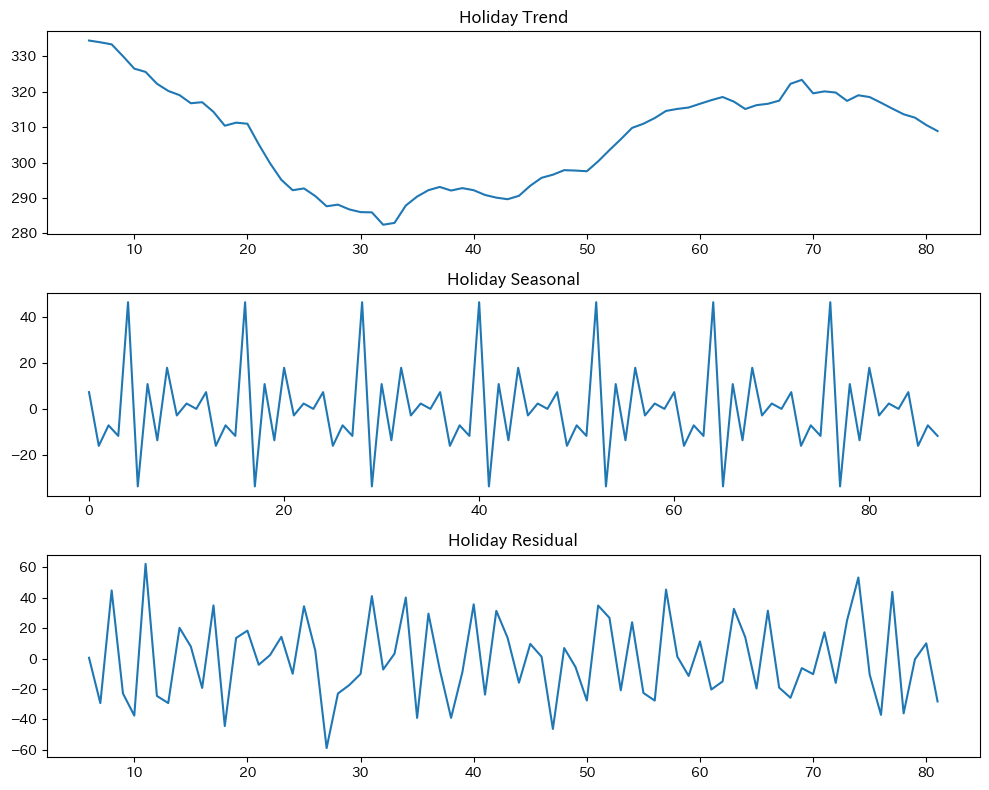

In [212]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(holiday_trend)
axes[0].set_title('Holiday Trend')

# 季節成分のプロット
axes[1].plot(holiday_seasonal)
axes[1].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[2].plot(holiday_resid)
axes[2].set_title('Holiday Residual')

plt.tight_layout()
plt.show()



* 季節性について、年間を通じたパターンが平日とは異なる。

### 予測結果②

### 岡南地域のProphetモデル

In [213]:
#Prophetクラスをインスタンス化
weekday_model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `kounan_weekday_forecast` 平日の場合

In [214]:
#学習期間を2024年4月まで
weekday_model.fit(kounan_weekday_df[kounan_weekday_df['ds'] <= '2024-04-01'])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [215]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
kounan_weekday_future = weekday_model.make_future_dataframe(periods=12, freq='MS')


In [216]:
#予測を実行
kounan_weekday_forecast = weekday_model.predict(kounan_weekday_future)

#出力された予測値や、不確実性区間を確認
kounan_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,626.904379,599.514478,659.864819
1,2018-02-01,582.309281,549.541686,611.744475
2,2018-03-01,670.365840,638.253230,701.058909
3,2018-04-01,639.608336,607.590188,668.582707
4,2018-05-01,596.313206,565.836134,626.377417
...,...,...,...,...
83,2024-12-01,785.665631,757.097997,817.153097
84,2025-01-01,629.333329,597.104992,662.341180
85,2025-02-01,591.603633,560.892500,623.863957
86,2025-03-01,706.662021,675.563735,738.270456


Text(0.5, 1.0, 'Kounan Weekday Forecast')

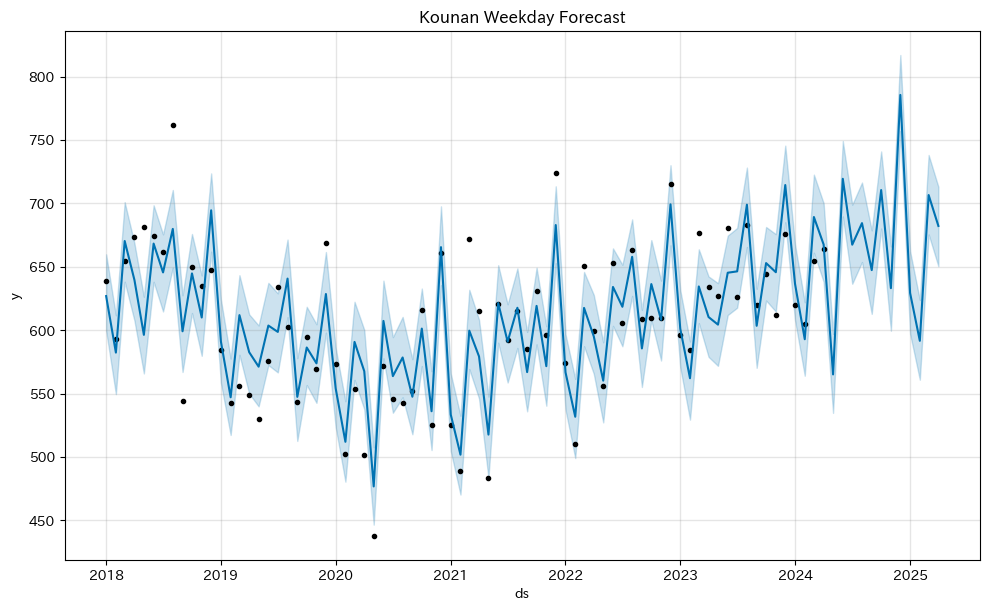

In [217]:
#グラフ上に可視化
fig_forecast = weekday_model.plot(kounan_weekday_forecast)
plt.title('Kounan Weekday Forecast')


In [218]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = kounan_weekday_forecast[(kounan_weekday_forecast['ds'] >= start_date) & (kounan_weekday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,565.073079,534.689356,597.068401
77,2024-06-01,719.477196,689.759784,749.279129
78,2024-07-01,667.471797,636.622384,699.015463
79,2024-08-01,684.481110,653.779773,716.530473
80,2024-09-01,647.416285,612.839541,678.762442
81,2024-10-01,710.593589,680.225166,741.067115
82,2024-11-01,633.143431,599.569405,666.086898
83,2024-12-01,785.665631,757.097997,817.153097
84,2025-01-01,629.333329,597.104992,662.341180
85,2025-02-01,591.603633,560.892500,623.863957


In [219]:
# 予測の実施（全期間）
kounan_weekday_df_future = weekday_model.make_future_dataframe(periods=12,
                                    freq='M')
kounan_weekday_df_pred = weekday_model.predict(kounan_weekday_df_future)

# 元のデータセットに予測値を結合
kounan_weekday_df['Predict'] = kounan_weekday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [220]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = kounan_weekday_df.iloc[:-12].loc[:, 'Predict']
test_pred = kounan_weekday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = kounan_weekday_df.iloc[:-12].loc[:, 'y']
y_test = kounan_weekday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
61.67329113261244
MAE:
47.954510902235405
MAPE:
0.08025724455735897


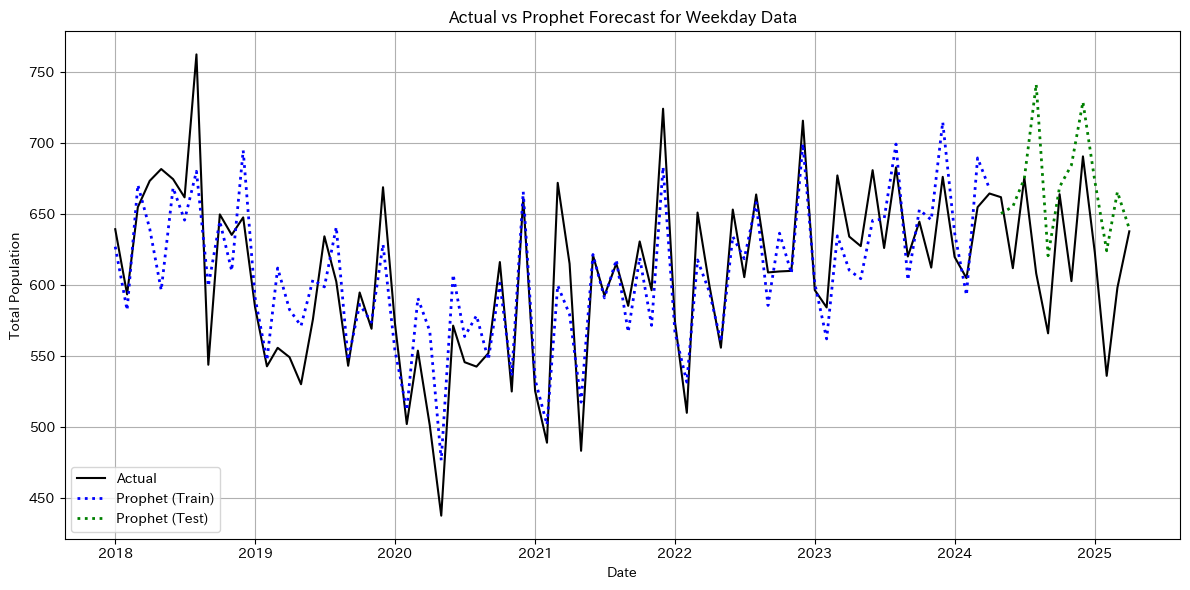

In [221]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(kounan_weekday_df['ds'], kounan_weekday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(kounan_weekday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(kounan_weekday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Weekday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### `kounan_holiday_forecast` 休日の場合

In [222]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)

#学習期間を2024年4月まで
holiday_model.fit(kounan_holiday_df[kounan_holiday_df['ds'] <= '2024-04-01'])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [223]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
kounan_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [224]:
#予測を実行
kounan_holiday_forecast = holiday_model.predict(kounan_holiday_future)

#出力された予測値や、不確実性区間を確認
kounan_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,342.427371,316.954746,370.574999
1,2018-02-01,301.384116,274.645300,326.992410
2,2018-03-01,315.061214,288.528907,340.097973
3,2018-04-01,328.997483,303.101104,356.159193
4,2018-05-01,372.979247,348.349385,400.015152
...,...,...,...,...
83,2024-12-01,283.585022,257.769297,311.527035
84,2025-01-01,358.699733,334.428484,385.118293
85,2025-02-01,299.757865,273.942166,326.339224
86,2025-03-01,331.206126,304.839070,357.167518


Text(0.5, 1.0, 'Kounan Holiday Forecast')

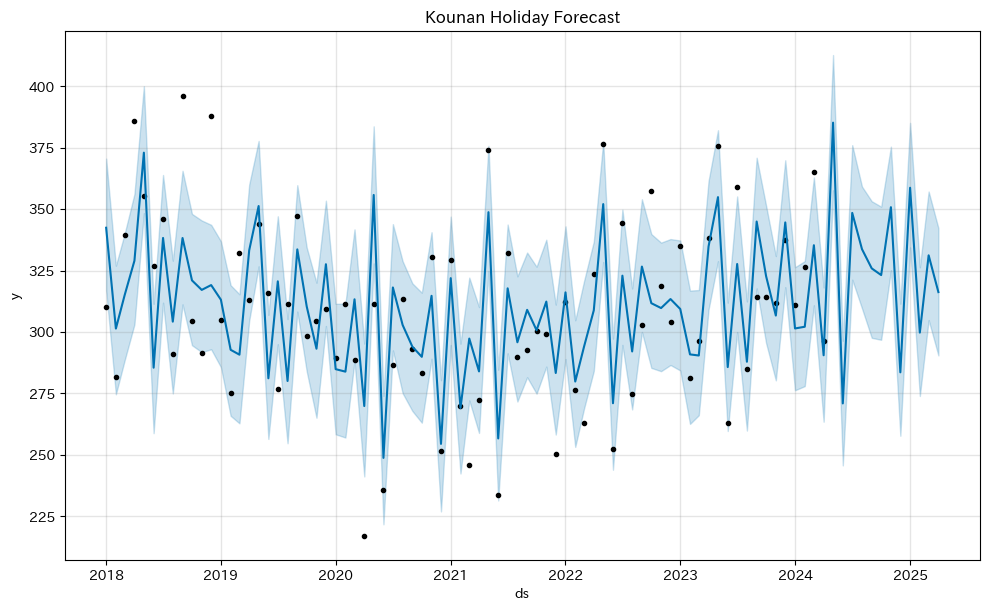

In [225]:
#グラフ上に可視化
fig_forecast = holiday_model.plot(kounan_holiday_forecast)
plt.title('Kounan Holiday Forecast')


In [226]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = kounan_holiday_forecast[(kounan_holiday_forecast['ds'] >= start_date) & (kounan_holiday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,385.198593,357.661529,412.715914
77,2024-06-01,270.932272,245.704456,296.431497
78,2024-07-01,348.454232,321.303560,376.036395
79,2024-08-01,333.712902,309.614576,359.185759
80,2024-09-01,325.882920,297.625634,353.218617
81,2024-10-01,323.167355,296.828641,351.004578
82,2024-11-01,350.790889,325.131367,375.421885
83,2024-12-01,283.585022,257.769297,311.527035
84,2025-01-01,358.699733,334.428484,385.118293
85,2025-02-01,299.757865,273.942166,326.339224


In [227]:
# 予測の実施（全期間）
kounan_holiday_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
kounan_holiday_df_pred = holiday_model.predict(kounan_holiday_df_future)
# 元のデータセットに予測値を結合
kounan_holiday_df['Predict'] = kounan_holiday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [228]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = kounan_holiday_df.iloc[:-12].loc[:, 'Predict']
test_pred = kounan_holiday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = kounan_holiday_df.iloc[:-12].loc[:, 'y']
y_test = kounan_holiday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
48.916267055760876
MAE:
39.36543157058572
MAPE:
0.1307973828599552


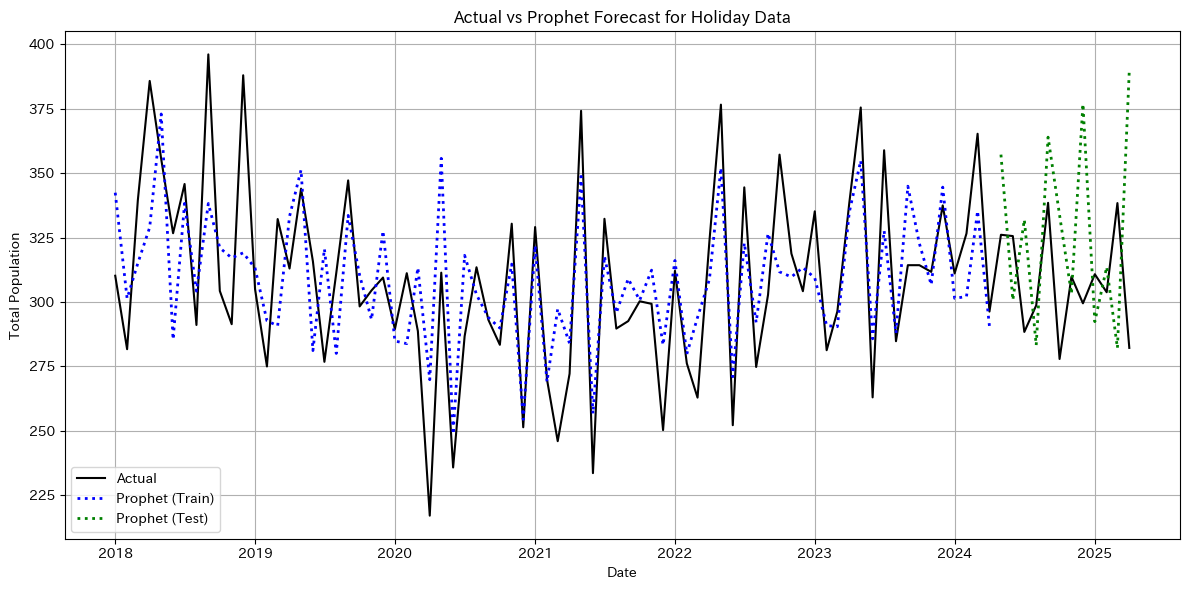

In [229]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(kounan_holiday_df['ds'], kounan_holiday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(kounan_holiday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(kounan_holiday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 平日とは異なる季節パターンが反映されている
* MAPEを見ると、平日の方が休日よりも若干予測精度が高い

## 西大寺地域の分析
西大寺地域のデータ 'saidaiji_month.csv' を基に、過去の傾向と将来予測を分析。

### `saidaiji_df` の前処理

In [230]:

# saidaiji_df の前処理
saidaiji_df = pd.read_csv('saidaiji_month.csv', encoding="cp932", header=1)
saidaiji_df.head()

,西大寺,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,301.8,391.7,56.4,105.6,117.0,101.6,123.5,189.4,...,NaN,祝休日,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57.0
1,2018年2月,期間全体,302.5,400.6,53.9,98.7,116.7,103.7,130.7,199.3,...,NaN,祝休日,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9
2,2018年3月,期間全体,308.3,409.0,50.3,111.4,129.4,108.2,131.1,187.0,...,NaN,祝休日,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6
3,2018年4月,期間全体,313.9,421.1,77.8,106.5,122.4,100.8,127.9,199.5,...,NaN,祝休日,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1
4,2018年5月,期間全体,334.7,468.2,84.9,109.8,128.8,104.1,133.0,242.4,...,NaN,祝休日,106.0,148.4,31.4,33.8,42.9,30.5,42.0,73.6


In [231]:
saidaiji_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   西大寺          88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [232]:
saidaiji_df = saidaiji_df.rename(columns={'西大寺': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
saidaiji_df['ds'] = saidaiji_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
saidaiji_df['ds'] = pd.to_datetime(saidaiji_df['ds'])

# 不要な列を削除
columns_to_drop = [
    'Unnamed: 1',
    '男性',
    '女性',
    '20代',
    '30代',
    '40代',
    '50代',
    '60代',
    '70歳以上',
    'Unnamed: 10',
    'Unnamed: 20',
    'Unnamed: 21']


# columns_to_drop というリストに指定されている列のうち、kounan_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを kounan_df に格納
saidaiji_df = saidaiji_df.drop(columns=[col for col in columns_to_drop if col in saidaiji_df.columns])

saidaiji_df.head()

,ds,Unnamed: 11,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,平日,206.0,274.0,38.8,71.7,79.4,71.7,86.1,132.4,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57.0
1,2018-02-01,平日,199.1,276.6,34.4,64.4,76.5,70.2,90.0,140.4,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9
2,2018-03-01,平日,209.9,275.5,29.8,75.6,88.0,74.4,89.2,128.4,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6
3,2018-04-01,平日,207.5,280.3,48.1,71.0,82.1,67.1,87.1,132.4,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1
4,2018-05-01,平日,228.7,319.8,53.5,75.9,85.8,73.6,91.0,168.8,106.0,148.4,31.4,33.8,42.9,30.5,42.0,73.6


In [233]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

# 平日用のDataFrameを作成
saidaiji_weekday_df = saidaiji_df[['ds'] + demographic_columns].copy()


### 予測結果①

### 西大寺地域の季節性、トレンド分析


#### `saidaiji_weekday_df` 平日の場合

In [234]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
saidaiji_weekday_df['y'] = saidaiji_weekday_df['男性.1'] + saidaiji_weekday_df['女性.1']
saidaiji_weekday_df.head()


,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,206.0,274.0,38.8,71.7,79.4,71.7,86.1,132.4,480.0
1,2018-02-01,199.1,276.6,34.4,64.4,76.5,70.2,90.0,140.4,475.7
2,2018-03-01,209.9,275.5,29.8,75.6,88.0,74.4,89.2,128.4,485.4
3,2018-04-01,207.5,280.3,48.1,71.0,82.1,67.1,87.1,132.4,487.8
4,2018-05-01,228.7,319.8,53.5,75.9,85.8,73.6,91.0,168.8,548.5


In [235]:

weekady_result = seasonal_decompose(
    saidaiji_weekday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

weekady_trend = weekady_result.trend
weekady_seasonal = weekady_result.seasonal
weekady_resid = weekady_result.resid

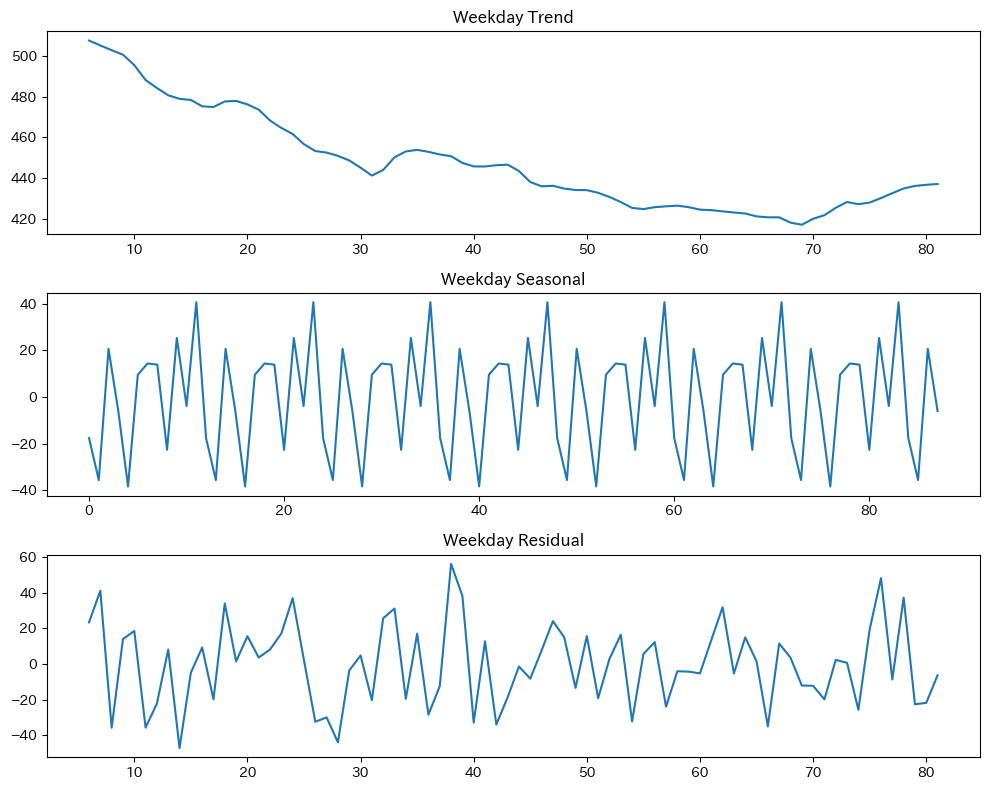

In [236]:


fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(weekady_trend)
axes[0].set_title('Weekday Trend')

# 季節成分のプロット
axes[1].plot(weekady_seasonal)
axes[1].set_title('Weekday Seasonal')

# 残差成分のプロット
axes[2].plot(weekady_resid)
axes[2].set_title('Weekday Residual')

plt.tight_layout()
plt.show()

* トレンド成分から全体的に緩やかな減少傾向
* 季節成分から周期的な動きが読み取れる

#### `saidaiji_holiday_df` 休日の場合

In [237]:
from numpy._core.defchararray import center
# 西大寺地域の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性.1', '女性.1', ...]）のサフィックスを.1から.2に変更して、
# 休日のデータに対応するカラム名を作成します。
saidaiji_holiday_demographic_columns = [col.replace('.1', '.2') for col in demographic_columns]
saidaiji_holiday_demographic_columns


['男性.2', '女性.2', '20代.2', '30代.2', '40代.2', '50代.2', '60代.2', '70歳以上.2']

In [238]:
# saidaiji_dfからからdsカラムと、saidaiji_holiday_demographic_columnsを抽出
# 新しいdfを作成
saidaiji_holiday_df = saidaiji_df[['ds'] + saidaiji_holiday_demographic_columns].copy()


In [239]:
saidaiji_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57.0
1,2018-02-01,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9
2,2018-03-01,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6
3,2018-04-01,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1
4,2018-05-01,106.0,148.4,31.4,33.8,42.9,30.5,42.0,73.6


In [240]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
saidaiji_holiday_df['y'] = saidaiji_holiday_df['男性.2'] + saidaiji_holiday_df['女性.2']
saidaiji_holiday_df.head()


,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57.0,213.5
1,2018-02-01,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9,227.2
2,2018-03-01,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6,231.9
3,2018-04-01,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1,247.2
4,2018-05-01,106.0,148.4,31.4,33.8,42.9,30.5,42.0,73.6,254.4


In [241]:

holiday_result = seasonal_decompose(
    saidaiji_holiday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

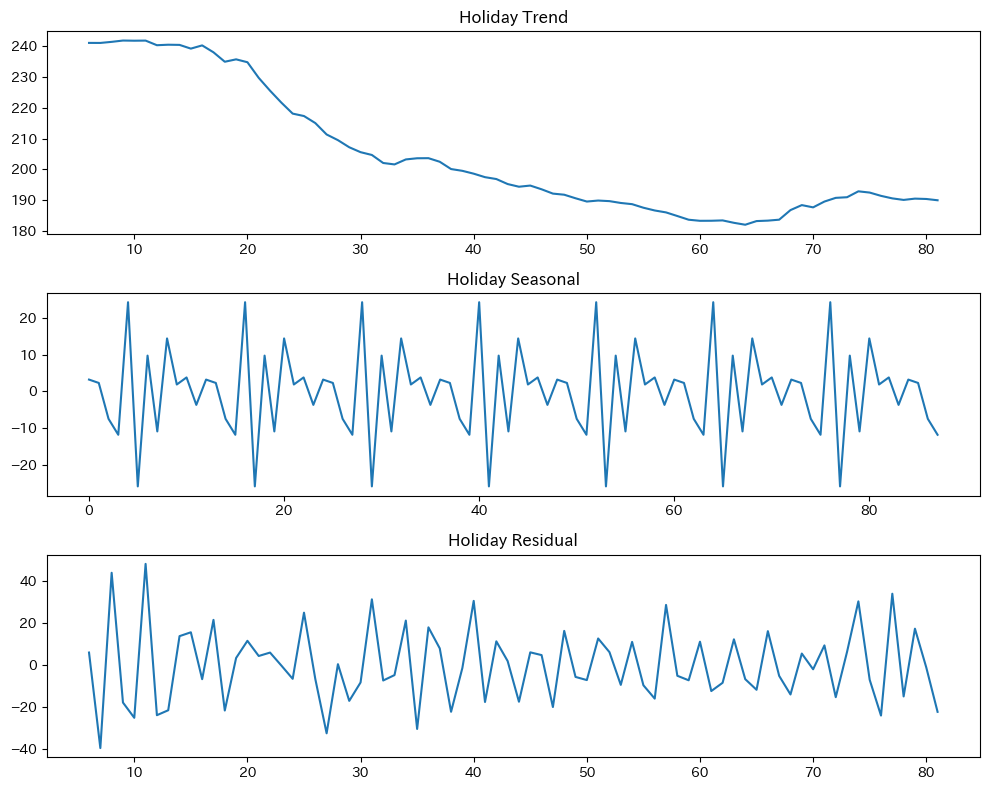

In [242]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(holiday_trend)
axes[0].set_title('Holiday Trend')

# 季節成分のプロット
axes[1].plot(holiday_seasonal)
axes[1].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[2].plot(holiday_resid)
axes[2].set_title('Holiday Residual')

plt.tight_layout()
plt.show()



* 平日同様に、トレンド成分から全体的に緩やかな減少傾向
* 平日同様に、季節成分から周期的な動きが読み取れる

### 予測結果②

### 西大寺地域のProphetモデル

In [243]:
#Prophetクラスをインポートし、インスタンス化
weekday_model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `saidaiji_weekday_forecast` 平日の場合

In [244]:
#学習期間を2024年4月まで
weekday_model.fit(saidaiji_weekday_df[saidaiji_weekday_df['ds'] <= '2024-04-01'])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [245]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
saidaiji_weekday_future = weekday_model.make_future_dataframe(periods=12, freq='MS')


In [246]:
#予測を実行
saidaiji_weekday_forecast = weekday_model.predict(saidaiji_weekday_future)

#出力された予測値や、不確実性区間を確認
saidaiji_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,481.317065,457.182767,506.790426
1,2018-02-01,469.874290,446.168161,496.211637
2,2018-03-01,521.659600,499.234696,548.589946
3,2018-04-01,493.841213,471.742425,519.999630
4,2018-05-01,470.851248,447.458424,496.979053
...,...,...,...,...
83,2024-12-01,449.827951,426.763849,475.000788
84,2025-01-01,363.631514,338.922925,386.759348
85,2025-02-01,363.480529,340.272163,386.795739
86,2025-03-01,411.050499,387.291100,436.608997


Text(0.5, 1.0, 'Saidaiji Weekday Forecast')

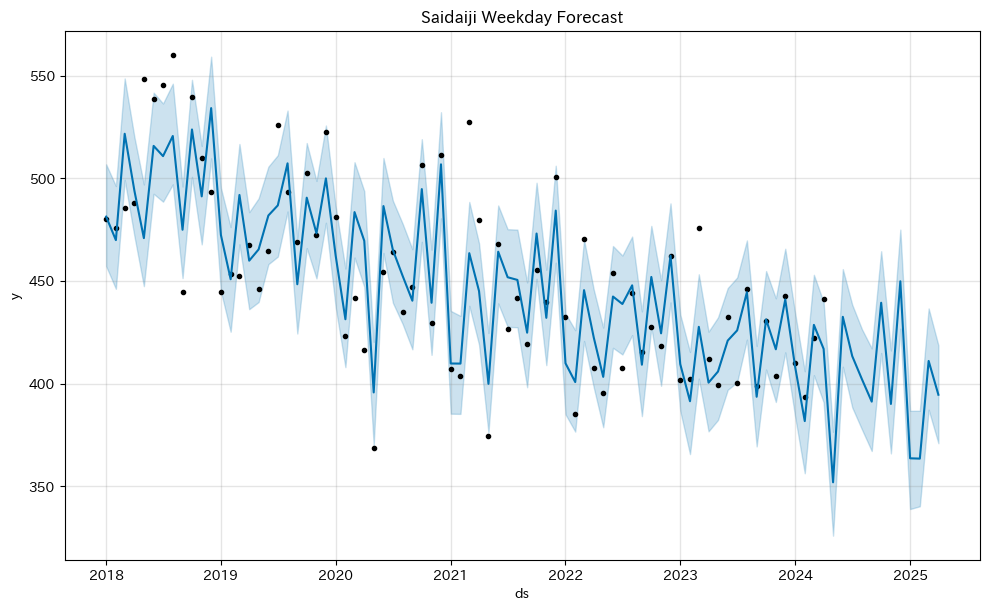

In [247]:
#グラフ上に可視化
fig_forecast = weekday_model.plot(saidaiji_weekday_forecast)
plt.title('Saidaiji Weekday Forecast')


In [248]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = saidaiji_weekday_forecast[(saidaiji_weekday_forecast['ds'] >= start_date) & (saidaiji_weekday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,351.942906,325.949070,376.535469
77,2024-06-01,432.524521,408.226477,455.773194
78,2024-07-01,413.387506,388.413979,438.399274
79,2024-08-01,402.086795,377.626450,426.456987
80,2024-09-01,391.222032,367.185562,417.171554
81,2024-10-01,439.378875,414.907282,464.468064
82,2024-11-01,390.098088,366.000231,416.152627
83,2024-12-01,449.827951,426.763849,475.000788
84,2025-01-01,363.631514,338.922925,386.759348
85,2025-02-01,363.480529,340.272163,386.795739


In [249]:
# 予測の実施（全期間）
saidaiji_weekday_df_future = weekday_model.make_future_dataframe(periods=12,
                                    freq='M')
saidaiji_weekday_df_pred = weekday_model.predict(saidaiji_weekday_df_future)

# 元のデータセットに予測値を結合
saidaiji_weekday_df['Predict'] = saidaiji_weekday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [250]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = saidaiji_weekday_df.iloc[:-12].loc[:, 'Predict']
test_pred = saidaiji_weekday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = saidaiji_weekday_df.iloc[:-12].loc[:, 'y']
y_test = saidaiji_weekday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
43.461814018829486
MAE:
38.41978475679485
MAPE:
0.08632039887578817


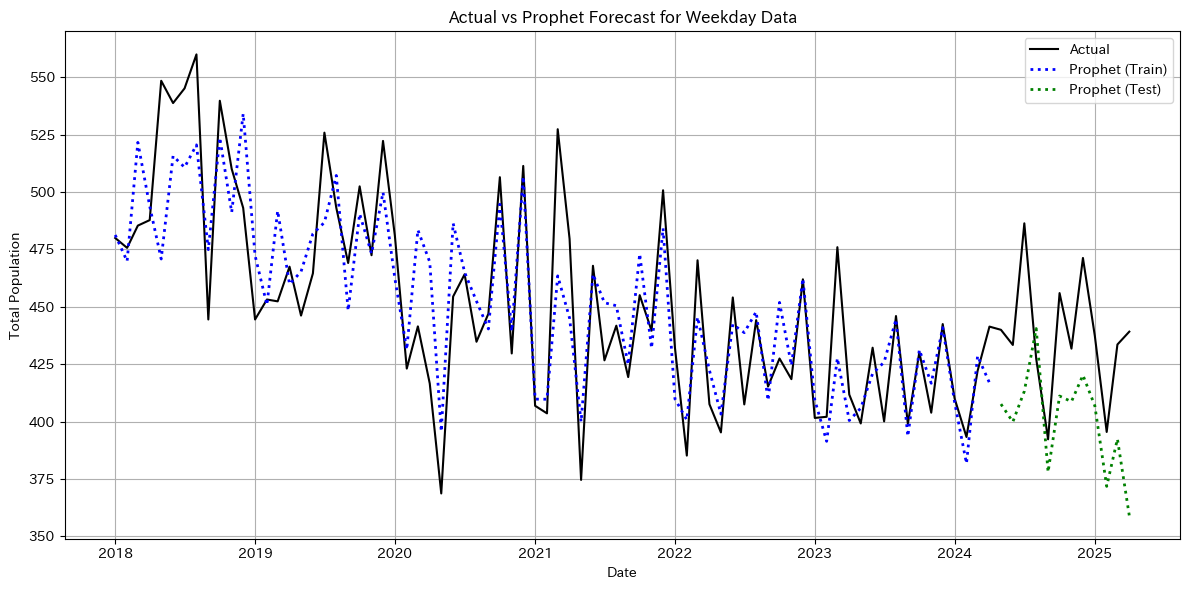

In [251]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(saidaiji_weekday_df['ds'], saidaiji_weekday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(saidaiji_weekday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(saidaiji_weekday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Weekday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 実際の平日データ（黒線）の傾向や季節性を比較的捉えている
* 一部のピークや谷の部分では、実際の値と予測値にずれがある。特に、データの減少傾向は予測できても、変動の振幅については実際のデータとの乖離がある

#### `saidaiji_holiday_forecast` 休日の場合

In [252]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)

#学習期間を2024年4月まで
holiday_model.fit(saidaiji_holiday_df[saidaiji_holiday_df['ds'] <= '2024-04-01'])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [253]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
saidaiji_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [254]:
#予測を実行
saidaiji_holiday_forecast = holiday_model.predict(saidaiji_holiday_future)

#出力された予測値や、不確実性区間を確認
saidaiji_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,247.937752,229.655552,266.171723
1,2018-02-01,241.417878,222.932486,260.026829
2,2018-03-01,231.343618,213.202316,250.242311
3,2018-04-01,235.414335,216.550521,253.091209
4,2018-05-01,267.110949,248.629942,283.823162
...,...,...,...,...
83,2024-12-01,153.097534,133.903365,172.573368
84,2025-01-01,181.630804,164.914222,199.837120
85,2025-02-01,168.550948,151.554325,186.783065
86,2025-03-01,167.890681,149.751879,186.527808


Text(0.5, 1.0, 'Kounan Holiday Forecast')

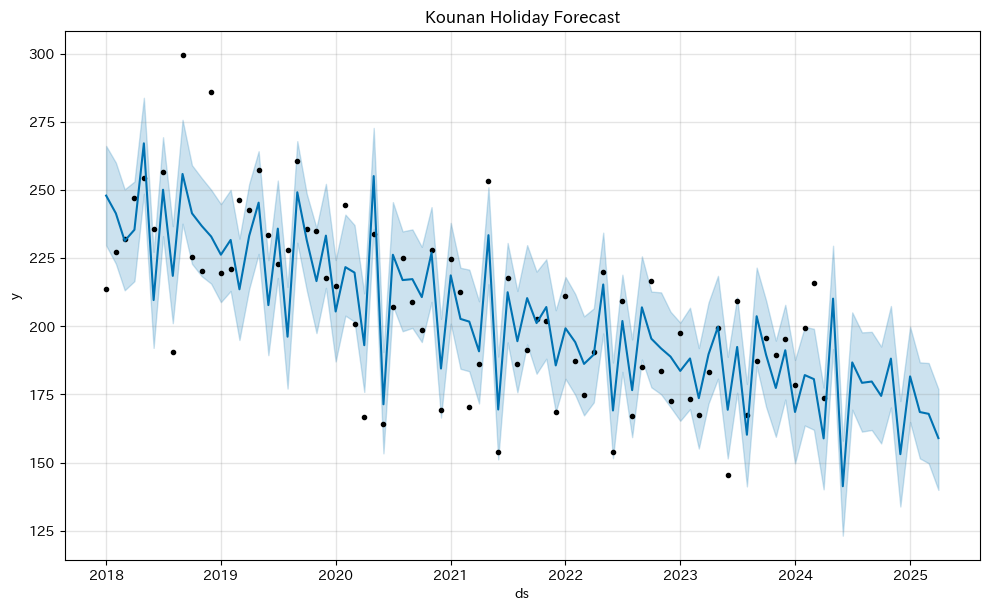

In [255]:
#グラフ上に可視化
fig_forecast = holiday_model.plot(saidaiji_holiday_forecast)
plt.title('Kounan Holiday Forecast')


In [256]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = saidaiji_holiday_forecast[(saidaiji_holiday_forecast['ds'] >= start_date) & (saidaiji_holiday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,210.148947,191.627991,229.546962
77,2024-06-01,141.332916,123.197368,158.042214
78,2024-07-01,186.750938,169.424218,205.099672
79,2024-08-01,179.268156,161.368395,197.778374
80,2024-09-01,179.743144,161.960345,197.971116
81,2024-10-01,174.470341,157.042085,192.576816
82,2024-11-01,188.155880,170.228732,207.452582
83,2024-12-01,153.097534,133.903365,172.573368
84,2025-01-01,181.630804,164.914222,199.837120
85,2025-02-01,168.550948,151.554325,186.783065


In [257]:
# 予測の実施（全期間）
saidaiji_holiday_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
saidaiji_holiday_df_pred = holiday_model.predict(saidaiji_holiday_df_future)
# 元のデータセットに予測値を結合
saidaiji_holiday_df['Predict'] = saidaiji_holiday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [258]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = saidaiji_holiday_df.iloc[:-12].loc[:, 'Predict']
test_pred = saidaiji_holiday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = saidaiji_holiday_df.iloc[:-12].loc[:, 'y']
y_test = saidaiji_holiday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
29.944864339313387
MAE:
24.30433170193451
MAPE:
0.12589983929242168


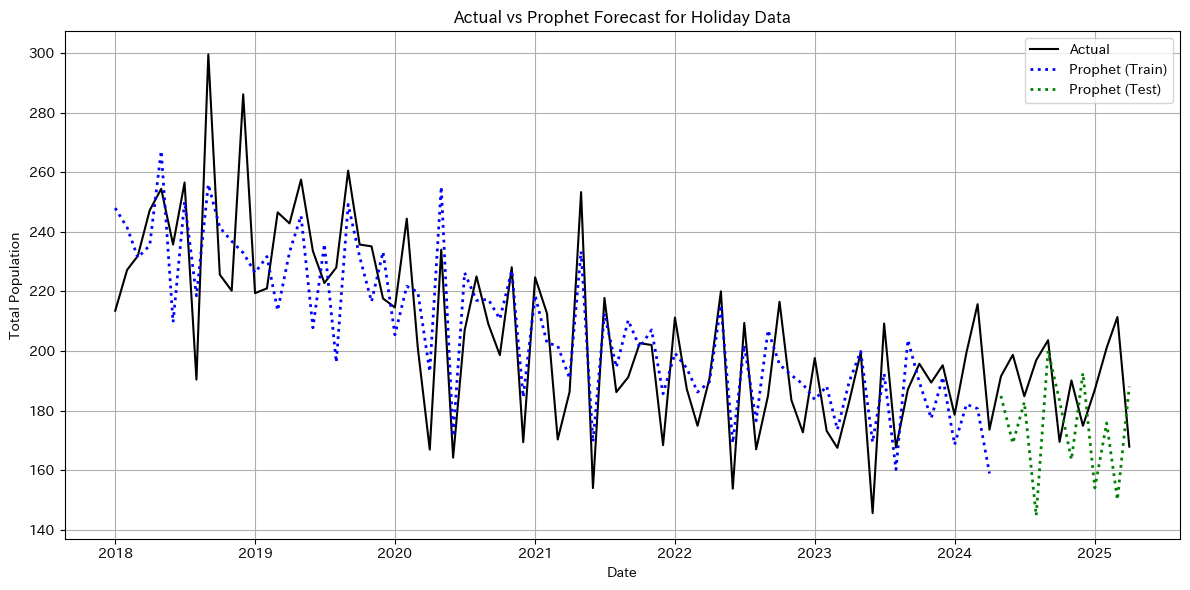

In [259]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(saidaiji_holiday_df['ds'], saidaiji_holiday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(saidaiji_holiday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(saidaiji_holiday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 一部のピークや谷の部分では、実際の値と予測値にずれが見られる。特に、変動の振幅や急激な変化に対して、モデルが追従しきれていない箇所があるように見受けられる。2023年の後半から実測値が上昇傾向にあり、予測が反映されていない。
* 平日のMAPE（約8.6%）と比較すると、休日の予測は若干難易度が高い、または変動が大きいため、誤差もやや大きい。

## 浜・原尾島地域の分析
浜・原尾島地域のデータ 'hama_haraojima_month.csv' を基に、過去の傾向と将来予測を分析。

### `hama_haraojima_df` の前処理

In [260]:

# hama_haraojima_df の前処理
hama_haraojima_df = pd.read_csv('hama_haraojima_month.csv', encoding="cp932", header=1)
hama_haraojima_df.head()

,浜・原尾島,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,434.1,552.3,129.9,144.5,175.0,151.8,202.1,183.1,...,NaN,祝休日,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6
1,2018年2月,期間全体,399.2,503.4,124.6,126.9,160.0,131.3,183.8,175.9,...,NaN,祝休日,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3
2,2018年3月,期間全体,467.7,570.9,154.4,148.8,180.2,155.4,225.1,174.7,...,NaN,祝休日,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7
3,2018年4月,期間全体,469.7,566.4,143.9,161.6,174.6,147.4,203.2,205.4,...,NaN,祝休日,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0
4,2018年5月,期間全体,462.0,594.6,155.9,154.7,171.1,152.4,199.0,223.6,...,NaN,祝休日,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8


In [261]:
hama_haraojima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   浜・原尾島        88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [262]:
hama_haraojima_df = hama_haraojima_df.rename(columns={'浜・原尾島': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
hama_haraojima_df['ds'] = hama_haraojima_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
hama_haraojima_df['ds'] = pd.to_datetime(hama_haraojima_df['ds'])

# 不要な列を削除
columns_to_drop = [
    'Unnamed: 1',
    '男性',
    '女性',
    '20代',
    '30代',
    '40代',
    '50代',
    '60代',
    '70歳以上',
    'Unnamed: 10',
    'Unnamed: 20',
    'Unnamed: 21']


# columns_to_drop というリストに指定されている列のうち、kounan_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを hama_haraojima_df に格納
hama_haraojima_df = hama_haraojima_df.drop(columns=[col for col in columns_to_drop if col in hama_haraojima_df.columns])

hama_haraojima_df.head()

,ds,Unnamed: 11,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,平日,291.0,371.2,88.1,95.6,118.9,101.3,139.9,118.5,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6
1,2018-02-01,平日,268.0,328.6,82.6,83.5,107.6,87.0,127.2,108.6,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3
2,2018-03-01,平日,303.5,376.1,96.7,96.6,122.4,101.2,150.8,112.0,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7
3,2018-04-01,平日,300.8,370.6,89.5,102.0,113.9,93.9,134.7,137.4,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0
4,2018-05-01,平日,302.6,395.4,100.0,99.8,113.6,102.4,137.5,144.8,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8


In [263]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

# 平日用のDataFrameを作成
hama_haraojima_weekday_df = hama_haraojima_df[['ds'] + demographic_columns].copy()


### 予測結果①

### 浜・原尾島地域の季節性、トレンド分析


#### `hama_haraojima_weekday_df` 平日の場合

In [264]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
hama_haraojima_weekday_df['y'] = hama_haraojima_weekday_df['男性.1'] + hama_haraojima_weekday_df['女性.1']
hama_haraojima_weekday_df.head()


,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,291.0,371.2,88.1,95.6,118.9,101.3,139.9,118.5,662.2
1,2018-02-01,268.0,328.6,82.6,83.5,107.6,87.0,127.2,108.6,596.6
2,2018-03-01,303.5,376.1,96.7,96.6,122.4,101.2,150.8,112.0,679.6
3,2018-04-01,300.8,370.6,89.5,102.0,113.9,93.9,134.7,137.4,671.4
4,2018-05-01,302.6,395.4,100.0,99.8,113.6,102.4,137.5,144.8,698.0


In [265]:
hama_haraojima_weekday_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ds       88 non-null     datetime64[ns]
 1   男性.1     88 non-null     float64       
 2   女性.1     88 non-null     float64       
 3   20代.1    88 non-null     float64       
 4   30代.1    88 non-null     float64       
 5   40代.1    88 non-null     float64       
 6   50代.1    88 non-null     float64       
 7   60代.1    88 non-null     float64       
 8   70歳以上.1  88 non-null     float64       
 9   y        88 non-null     float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 7.2 KB


In [266]:
print(hama_haraojima_weekday_df['y'].isnull().sum())

2


In [267]:
missing_y_rows = hama_haraojima_weekday_df[hama_haraojima_weekday_df['y'].isnull()]
display(missing_y_rows)

,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
88,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [268]:
display(hama_haraojima_weekday_df)

,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,291.0,371.2,88.1,95.6,118.9,101.3,139.9,118.5,662.2
1,2018-02-01,268.0,328.6,82.6,83.5,107.6,87.0,127.2,108.6,596.6
2,2018-03-01,303.5,376.1,96.7,96.6,122.4,101.2,150.8,112.0,679.6
3,2018-04-01,300.8,370.6,89.5,102.0,113.9,93.9,134.7,137.4,671.4
4,2018-05-01,302.6,395.4,100.0,99.8,113.6,102.4,137.5,144.8,698.0
...,...,...,...,...,...,...,...,...,...,...
85,2025-02-01,214.8,281.2,60.8,76.9,92.0,79.3,72.0,115.0,496.0
86,2025-03-01,251.5,310.1,65.7,84.2,111.3,91.2,82.9,126.3,561.6
87,2025-04-01,280.6,352.4,88.5,89.9,126.5,100.5,86.3,141.4,633.0
88,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [269]:
# 'y'列に欠損値がある行を削除します
hama_haraojima_weekday_df_cleaned = hama_haraojima_weekday_df.dropna(subset=['y']).copy()

print("欠損値削除後の 'y' 列の欠損値数:")
print(hama_haraojima_weekday_df_cleaned['y'].isnull().sum())

print("\n欠損値削除後のデータフレームの行数:")
print(len(hama_haraojima_weekday_df_cleaned))

# 削除後のデータフレームの末尾を表示して確認
print("\n欠損値削除後のデータフレームの末尾:")
display(hama_haraojima_weekday_df_cleaned.tail())

欠損値削除後の 'y' 列の欠損値数:
0

欠損値削除後のデータフレームの行数:
88

欠損値削除後のデータフレームの末尾:


,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
83,2024-12-01,276.3,345.2,82.7,96.6,114.7,98.9,88.1,140.3,621.5
84,2025-01-01,252.8,315.1,76.6,83.5,105.6,93.8,83.5,124.8,567.9
85,2025-02-01,214.8,281.2,60.8,76.9,92.0,79.3,72.0,115.0,496.0
86,2025-03-01,251.5,310.1,65.7,84.2,111.3,91.2,82.9,126.3,561.6
87,2025-04-01,280.6,352.4,88.5,89.9,126.5,100.5,86.3,141.4,633.0


In [270]:

weekady_result = seasonal_decompose(
    hama_haraojima_weekday_df_cleaned['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

weekady_trend = weekady_result.trend
weekady_seasonal = weekady_result.seasonal
weekady_resid = weekady_result.resid

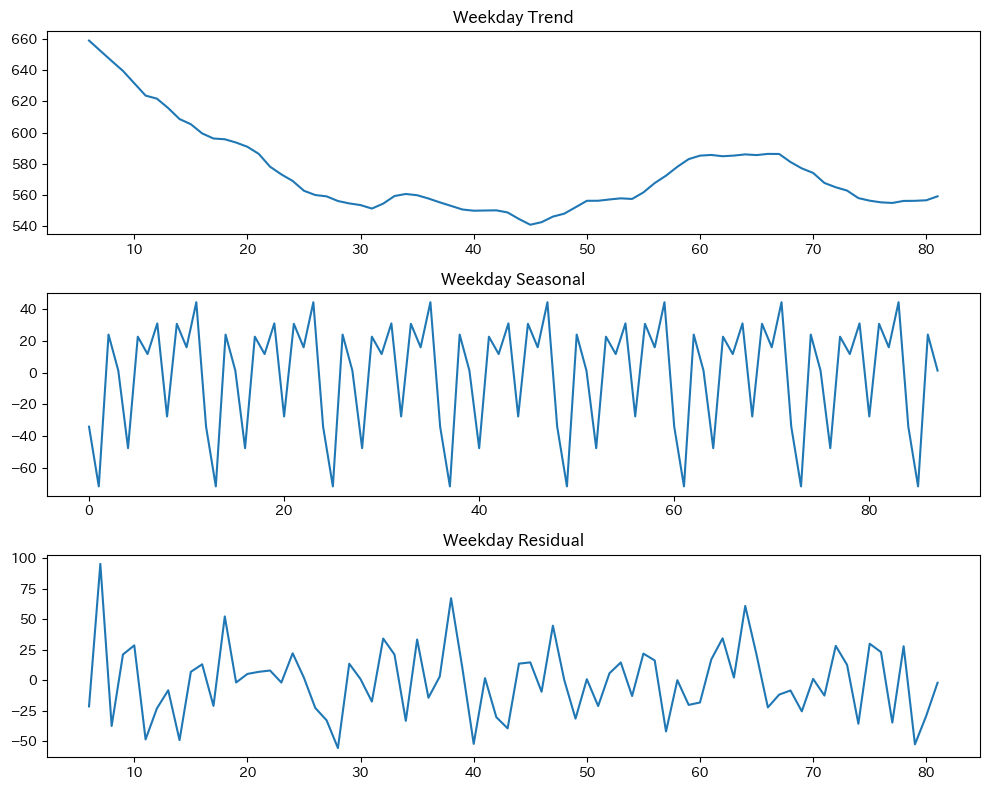

In [271]:


fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(weekady_trend)
axes[0].set_title('Weekday Trend')

# 季節成分のプロット
axes[1].plot(weekady_seasonal)
axes[1].set_title('Weekday Seasonal')

# 残差成分のプロット
axes[2].plot(weekady_resid)
axes[2].set_title('Weekday Residual')

plt.tight_layout()
plt.show()

* 季節成分のグラフを見ると、年間を通して周期的な変動がある

#### `hama_haraojima_holiday_df` 休日の場合

In [272]:
from numpy._core.defchararray import center
# 浜・原尾島地域の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性.1', '女性.1', ...]）のサフィックスを.1から.2に変更して、
# 休日のデータに対応するカラム名を作成します。
hama_haraojima_holiday_demographic_columns = [col.replace('.1', '.2') for col in demographic_columns]
hama_haraojima_holiday_demographic_columns


['男性.2', '女性.2', '20代.2', '30代.2', '40代.2', '50代.2', '60代.2', '70歳以上.2']

In [273]:
# hama_haraojima_dfからからdsカラムと、hama_haraojima_holiday_demographic_columnsを抽出
# 新しいdfを作成
hama_haraojima_holiday_df = hama_haraojima_df[['ds'] + hama_haraojima_holiday_demographic_columns].copy()


In [274]:
hama_haraojima_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6
1,2018-02-01,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3
2,2018-03-01,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7
3,2018-04-01,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0
4,2018-05-01,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8


In [275]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
hama_haraojima_holiday_df['y'] = hama_haraojima_holiday_df['男性.2'] + hama_haraojima_holiday_df['女性.2']
hama_haraojima_holiday_df.head()


,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6,324.2
1,2018-02-01,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3,306.0
2,2018-03-01,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7,359.0
3,2018-04-01,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0,364.7
4,2018-05-01,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8,358.7


In [276]:
display(hama_haraojima_holiday_df)

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6,324.2
1,2018-02-01,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3,306.0
2,2018-03-01,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7,359.0
3,2018-04-01,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0,364.7
4,2018-05-01,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8,358.7
...,...,...,...,...,...,...,...,...,...,...
85,2025-02-01,122.1,156.9,31.9,45.4,55.4,45.4,39.9,61.0,279.0
86,2025-03-01,146.0,175.9,37.6,51.9,64.1,53.8,47.0,67.6,321.9
87,2025-04-01,129.9,155.5,38.5,44.8,58.3,44.9,39.4,59.5,285.4
88,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [277]:
# 'y'列に欠損値がある行を削除します
hama_haraojima_holiday_df_cleaned = hama_haraojima_holiday_df.dropna(subset=['y']).copy()

print("欠損値削除後の 'y' 列の欠損値数:")
print(hama_haraojima_holiday_df_cleaned['y'].isnull().sum())

print("\n欠損値削除後のデータフレームの行数:")
print(len(hama_haraojima_holiday_df_cleaned))

# 削除後のデータフレームの末尾を表示して確認
print("\n欠損値削除後のデータフレームの末尾:")
display(hama_haraojima_holiday_df_cleaned.tail())

欠損値削除後の 'y' 列の欠損値数:
0

欠損値削除後のデータフレームの行数:
88

欠損値削除後のデータフレームの末尾:


,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
83,2024-12-01,122.3,141.3,34.8,39.1,52.7,41.4,38.5,57.0,263.6
84,2025-01-01,123.4,151.2,33.5,42.7,53.5,46.3,39.4,59.2,274.6
85,2025-02-01,122.1,156.9,31.9,45.4,55.4,45.4,39.9,61.0,279.0
86,2025-03-01,146.0,175.9,37.6,51.9,64.1,53.8,47.0,67.6,321.9
87,2025-04-01,129.9,155.5,38.5,44.8,58.3,44.9,39.4,59.5,285.4


In [278]:

holiday_result = seasonal_decompose(
    hama_haraojima_holiday_df_cleaned['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

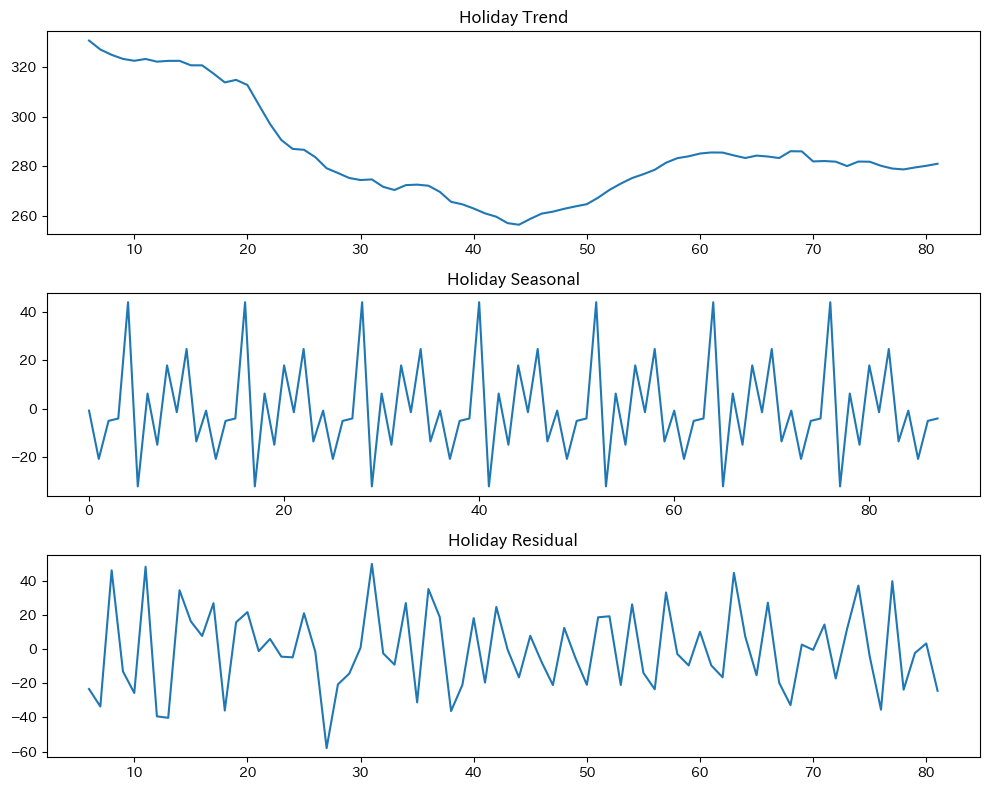

In [279]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(holiday_trend)
axes[0].set_title('Holiday Trend')

# 季節成分のプロット
axes[1].plot(holiday_seasonal)
axes[1].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[2].plot(holiday_resid)
axes[2].set_title('Holiday Residual')

plt.tight_layout()
plt.show()



* 季節成分のグラフから、休日も年間を通して明確な周期的な変動が見られる

### 予測結果②

### 浜・原尾島地域のProphetモデル

In [280]:
#Prophetクラスをインスタンス化
weekday_model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `hama_haraojima_weekday_forecast` 平日の場合

In [281]:
#学習期間を2024年4月まで
weekday_model.fit(hama_haraojima_weekday_df[hama_haraojima_weekday_df['ds'] <= '2024-04-01'])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [282]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
hama_haraojima_weekday_future = weekday_model.make_future_dataframe(periods=12, freq='MS')


In [283]:
#予測を実行
hama_haraojima_weekday_forecast = weekday_model.predict(hama_haraojima_weekday_future)

#出力された予測値や、不確実性区間を確認
hama_haraojima_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,636.473810,606.537774,665.911649
1,2018-02-01,592.218588,560.142729,623.101185
2,2018-03-01,690.797209,662.444175,722.898169
3,2018-04-01,662.603200,633.318429,692.774615
4,2018-05-01,624.163742,594.099151,653.252087
...,...,...,...,...
83,2024-12-01,649.939940,617.877630,678.564117
84,2025-01-01,534.168401,504.825578,564.377262
85,2025-02-01,510.534291,481.817878,541.703407
86,2025-03-01,600.399748,570.788640,631.320029


Text(0.5, 1.0, 'Hama_Haraojima Weekday Forecast')

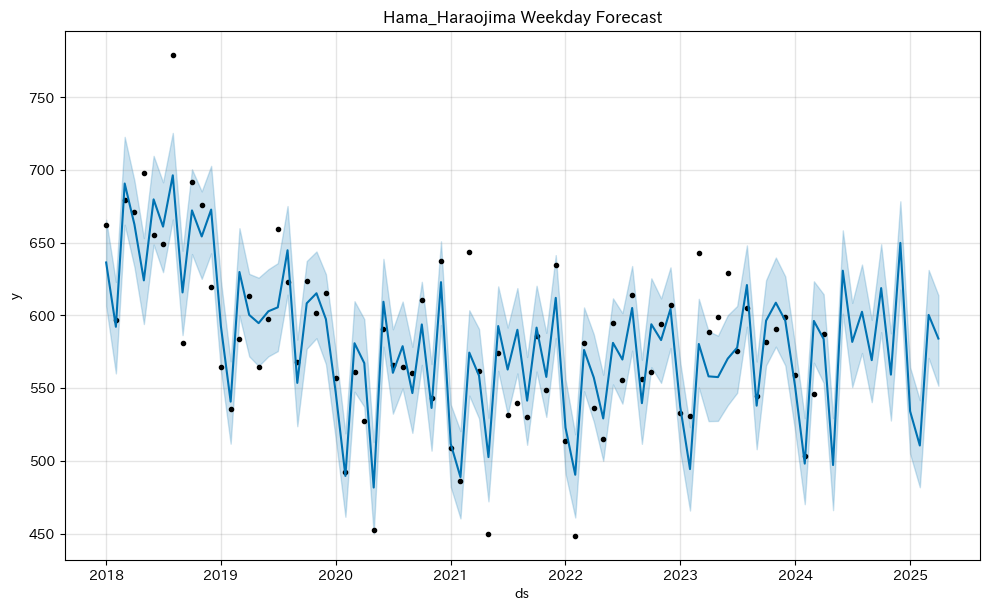

In [284]:
#グラフ上に可視化
fig_forecast = weekday_model.plot(hama_haraojima_weekday_forecast)
plt.title('Hama_Haraojima Weekday Forecast')


In [285]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = hama_haraojima_weekday_forecast[(hama_haraojima_weekday_forecast['ds'] >= start_date) & (hama_haraojima_weekday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,497.098568,466.072090,529.374503
77,2024-06-01,630.826088,601.240182,658.580274
78,2024-07-01,581.815335,550.727053,608.666082
79,2024-08-01,602.555474,574.195163,635.031766
80,2024-09-01,569.275375,540.367352,596.968745
81,2024-10-01,618.849232,588.550343,648.988685
82,2024-11-01,559.306994,527.729603,587.755074
83,2024-12-01,649.939940,617.877630,678.564117
84,2025-01-01,534.168401,504.825578,564.377262
85,2025-02-01,510.534291,481.817878,541.703407


In [286]:
# 予測の実施（全期間）
hama_haraojima_weekday_df_future = weekday_model.make_future_dataframe(periods=12,
                                    freq='M')
hama_haraojima_weekday_df_pred = weekday_model.predict(hama_haraojima_weekday_df_future)

# 元のデータセットに予測値を結合
hama_haraojima_weekday_df_cleaned['Predict'] = hama_haraojima_weekday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [287]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = hama_haraojima_weekday_df_cleaned.iloc[:-12].loc[:, 'Predict']
test_pred = hama_haraojima_weekday_df_cleaned.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = hama_haraojima_weekday_df_cleaned.iloc[:-12].loc[:, 'y']
y_test = hama_haraojima_weekday_df_cleaned.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
48.559526699614565
MAE:
37.30498663313906
MAPE:
0.06674461108470904


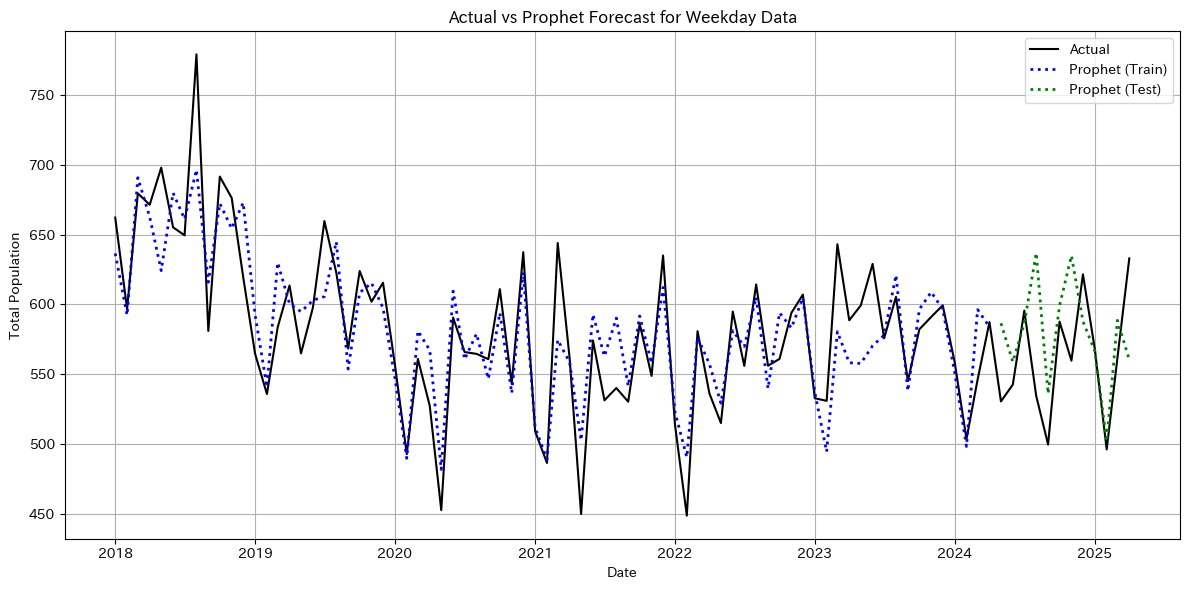

In [288]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(hama_haraojima_weekday_df_cleaned['ds'], hama_haraojima_weekday_df_cleaned['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(hama_haraojima_weekday_df_cleaned['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(hama_haraojima_weekday_df_cleaned['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Weekday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### `hama_haraojima_holiday_forecast` 休日の場合

In [289]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)

#学習期間を2024年4月まで
holiday_model.fit(hama_haraojima_holiday_df[hama_haraojima_holiday_df['ds'] <= '2024-04-01'])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [290]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
hama_haraojima_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [291]:
#予測を実行
hama_haraojima_holiday_forecast = holiday_model.predict(hama_haraojima_holiday_future)

#出力された予測値や、不確実性区間を確認
hama_haraojima_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,343.422412,321.343238,366.135291
1,2018-02-01,312.699024,288.490778,336.125464
2,2018-03-01,329.947421,306.825181,352.768239
3,2018-04-01,338.511347,313.828096,361.283902
4,2018-05-01,380.156125,357.669581,403.432836
...,...,...,...,...
83,2024-12-01,248.630375,225.131919,271.603539
84,2025-01-01,316.375891,292.875528,338.230388
85,2025-02-01,283.286203,259.721394,304.738165
86,2025-03-01,295.774538,273.873522,319.395444


Text(0.5, 1.0, 'Kounan Holiday Forecast')

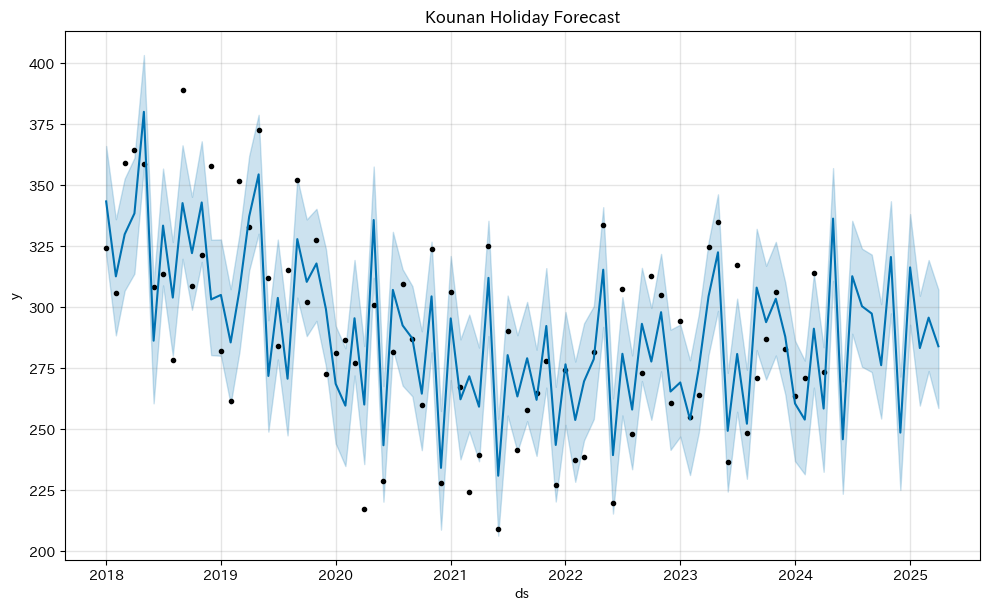

In [292]:
#グラフ上に可視化
fig_forecast = holiday_model.plot(hama_haraojima_holiday_forecast)
plt.title('Kounan Holiday Forecast')


In [293]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = hama_haraojima_holiday_forecast[(hama_haraojima_holiday_forecast['ds'] >= start_date) & (hama_haraojima_holiday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,336.376923,310.840036,357.085354
77,2024-06-01,245.909961,223.563037,269.636425
78,2024-07-01,312.767725,289.181467,335.475896
79,2024-08-01,300.445738,275.638813,324.042178
80,2024-09-01,297.442656,273.452861,321.612725
81,2024-10-01,276.271444,254.409171,301.317668
82,2024-11-01,320.632113,297.527687,343.502227
83,2024-12-01,248.630375,225.131919,271.603539
84,2025-01-01,316.375891,292.875528,338.230388
85,2025-02-01,283.286203,259.721394,304.738165


In [294]:
# 予測の実施（全期間）
hama_haraojima_holiday_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
hama_haraojima_holiday_df_cleaned_pred = holiday_model.predict(hama_haraojima_holiday_df_future)
# 元のデータセットに予測値を結合
hama_haraojima_holiday_df_cleaned['Predict'] = hama_haraojima_holiday_df_cleaned_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [295]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = hama_haraojima_holiday_df_cleaned.iloc[:-12].loc[:, 'Predict']
test_pred = hama_haraojima_holiday_df_cleaned.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = hama_haraojima_holiday_df_cleaned.iloc[:-12].loc[:, 'y']
y_test = hama_haraojima_holiday_df_cleaned.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
37.406950297561934
MAE:
33.00027634440948
MAPE:
0.11824539583699607


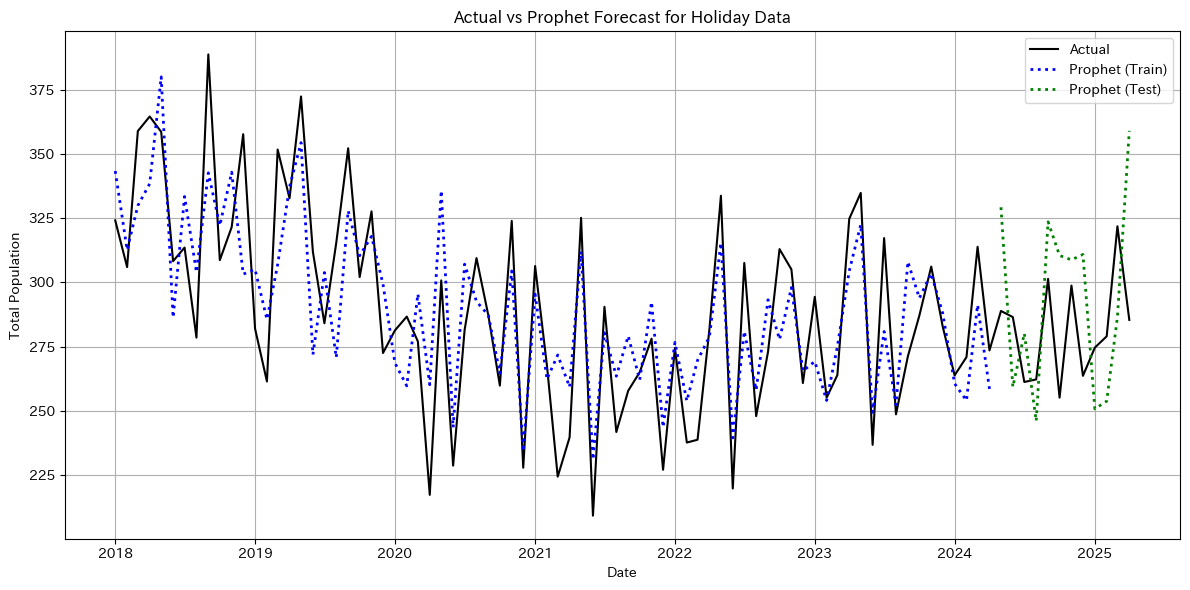

In [296]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(hama_haraojima_holiday_df_cleaned['ds'], hama_haraojima_holiday_df_cleaned['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(hama_haraojima_holiday_df_cleaned['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(hama_haraojima_holiday_df_cleaned['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 北長瀬地域の分析
北長瀬地域のデータ 'kitanagase_month.csv' を基に、過去の傾向と将来予測を分析。

### `kitanagase_df` の前処理

In [297]:


# kitanagase_df の前処理
kitanagase_df = pd.read_csv('kitanagase_month.csv', encoding="cp932", header=1)
kitanagase_df.head()

,北長瀬,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,470.3,495.7,166.1,176.1,186.7,142.1,133.8,161.2,...,NaN,祝休日,154.2,169.0,54.6,61.5,67.1,47.9,41.5,50.6
1,2018年2月,期間全体,412.7,434.6,162.7,161.2,171.3,121.3,121.1,109.6,...,NaN,祝休日,136.0,150.4,51.7,57.6,59.5,43.6,37.1,36.9
2,2018年3月,期間全体,491.3,504.1,192.2,171.8,199.1,131.2,138.0,163.1,...,NaN,祝休日,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8
3,2018年4月,期間全体,464.1,453.7,158.8,167.4,178.4,135.5,137.9,139.7,...,NaN,祝休日,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46.0
4,2018年5月,期間全体,488.4,470.4,195.9,165.1,186.7,138.2,128.6,144.4,...,NaN,祝休日,170.5,164.6,68.2,63.5,67.0,49.0,38.2,49.4


In [298]:
kitanagase_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   北長瀬          88 non-null     object 
 1   Unnamed: 1   88 non-null     object 
 2   男性           88 non-null     float64
 3   女性           88 non-null     float64
 4   20代          88 non-null     float64
 5   30代          88 non-null     float64
 6   40代          88 non-null     float64
 7   50代          88 non-null     float64
 8   60代          88 non-null     float64
 9   70歳以上        88 non-null     float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  88 non-null     object 
 12  男性.1         88 non-null     float64
 13  女性.1         88 non-null     float64
 14  20代.1        88 non-null     float64
 15  30代.1        88 non-null     float64
 16  40代.1        88 non-null     float64
 17  50代.1        88 non-null     float64
 18  60代.1        88 non-null     float64
 19  70歳以上.1   

In [299]:
kitanagase_df = kitanagase_df.rename(columns={'北長瀬': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
kitanagase_df['ds'] = kitanagase_df['ds'].astype(str).str.replace('年', '-').str.replace('月', '-01')
kitanagase_df['ds'] = pd.to_datetime(kitanagase_df['ds'])

# 不要な列を削除
columns_to_drop = [
    'Unnamed: 1',
    '男性',
    '女性',
    '20代',
    '30代',
    '40代',
    '50代',
    '60代',
    '70歳以上',
    'Unnamed: 10',
    'Unnamed: 20',
    'Unnamed: 21']


# columns_to_drop というリストに指定されている列のうち、kounan_df に実際に存在する列だけを選んで削除し、
#更新されたデータフレームを kounan_df に格納
kitanagase_df = kitanagase_df.drop(columns=[col for col in columns_to_drop if col in kitanagase_df.columns])

kitanagase_df.head()

,ds,Unnamed: 11,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,平日,316.1,326.8,111.5,114.5,119.7,94.3,92.3,110.6,154.2,169.0,54.6,61.5,67.1,47.9,41.5,50.6
1,2018-02-01,平日,276.7,284.2,110.9,103.6,111.8,77.7,84.0,72.7,136.0,150.4,51.7,57.6,59.5,43.6,37.1,36.9
2,2018-03-01,平日,322.1,321.9,123.6,106.9,126.3,85.4,98.5,103.3,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8
3,2018-04-01,平日,298.0,284.5,98.5,102.0,110.9,84.3,93.2,93.7,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46.0
4,2018-05-01,平日,317.9,305.8,127.7,101.6,119.6,89.3,90.4,95.0,170.5,164.6,68.2,63.5,67.0,49.0,38.2,49.4


In [300]:
# 中心市街地の平日滞在人口データを抽出するためのカラムリストを作成
demographic_columns = ['男性.1', '女性.1', '20代.1', '30代.1', '40代.1', '50代.1', '60代.1', '70歳以上.1']

# 平日用のDataFrameを作成
kitanagase_weekday_df = kitanagase_df[['ds'] + demographic_columns].copy()


### 予測結果①

### 北長瀬地域の季節性、トレンド分析


#### `kitanagase_weekday_df` 平日の場合

In [301]:
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
kitanagase_weekday_df['y'] = kitanagase_weekday_df['男性.1'] + kitanagase_weekday_df['女性.1']
kitanagase_weekday_df.head()


,ds,男性.1,女性.1,20代.1,30代.1,40代.1,50代.1,60代.1,70歳以上.1,y
0,2018-01-01,316.1,326.8,111.5,114.5,119.7,94.3,92.3,110.6,642.9
1,2018-02-01,276.7,284.2,110.9,103.6,111.8,77.7,84.0,72.7,560.9
2,2018-03-01,322.1,321.9,123.6,106.9,126.3,85.4,98.5,103.3,644.0
3,2018-04-01,298.0,284.5,98.5,102.0,110.9,84.3,93.2,93.7,582.5
4,2018-05-01,317.9,305.8,127.7,101.6,119.6,89.3,90.4,95.0,623.7


In [302]:

weekady_result = seasonal_decompose(
    kitanagase_weekday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

weekady_trend = weekady_result.trend
weekady_seasonal = weekady_result.seasonal
weekady_resid = weekady_result.resid

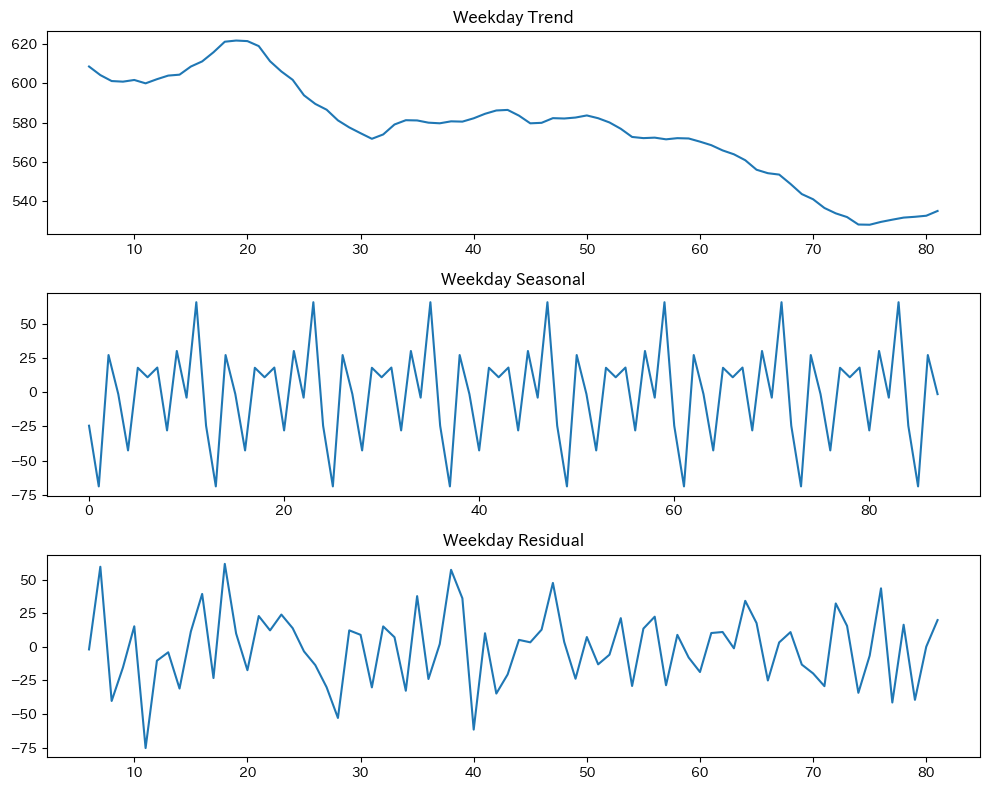

In [303]:


fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(weekady_trend)
axes[0].set_title('Weekday Trend')

# 季節成分のプロット
axes[1].plot(weekady_seasonal)
axes[1].set_title('Weekday Seasonal')

# 残差成分のプロット
axes[2].plot(weekady_resid)
axes[2].set_title('Weekday Residual')

plt.tight_layout()
plt.show()

* トレンド成分は分析期間全体を通して緩やかな減少傾向
* 明確な季節性があり、年間を通して繰り返しのパターンが見られる




#### `kitanagase_holiday_df` 休日の場合

In [304]:
from numpy._core.defchararray import center
# 北長瀬地域の休日滞在人口データを抽出するための列名リストを作成
# 既存のdemographic_columns（['男性.1', '女性.1', ...]）のサフィックスを.1から.2に変更して、
# 休日のデータに対応するカラム名を作成します。
kitanagase_holiday_demographic_columns = [col.replace('.1', '.2') for col in demographic_columns]
kitanagase_holiday_demographic_columns


['男性.2', '女性.2', '20代.2', '30代.2', '40代.2', '50代.2', '60代.2', '70歳以上.2']

In [305]:
# kitanagase_dfからからdsカラムと、kitanagase_holiday_demographic_columnsを抽出
# 新しいdfを作成
kitanagase_holiday_df = kitanagase_df[['ds'] + kitanagase_holiday_demographic_columns].copy()


In [306]:
kitanagase_holiday_df.head()

,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018-01-01,154.2,169.0,54.6,61.5,67.1,47.9,41.5,50.6
1,2018-02-01,136.0,150.4,51.7,57.6,59.5,43.6,37.1,36.9
2,2018-03-01,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8
3,2018-04-01,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46.0
4,2018-05-01,170.5,164.6,68.2,63.5,67.0,49.0,38.2,49.4


In [307]:
# 平日と同様に、休日
# Prophetに適用させるため、dsカラムとyに変換
# yは男性と女性を足した新しいカラムに変換
kitanagase_holiday_df['y'] = kitanagase_holiday_df['男性.2'] + kitanagase_holiday_df['女性.2']
kitanagase_holiday_df.head()


,ds,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2,y
0,2018-01-01,154.2,169.0,54.6,61.5,67.1,47.9,41.5,50.6,323.2
1,2018-02-01,136.0,150.4,51.7,57.6,59.5,43.6,37.1,36.9,286.4
2,2018-03-01,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8,351.3
3,2018-04-01,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46.0,335.2
4,2018-05-01,170.5,164.6,68.2,63.5,67.0,49.0,38.2,49.4,335.1


In [308]:

holiday_result = seasonal_decompose(
    kitanagase_holiday_df['y'], # 'y'カラムに対して分解を実行
    model="additive",   # or "multiplicative"
    period=12            # 月次周期なら12
)

holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

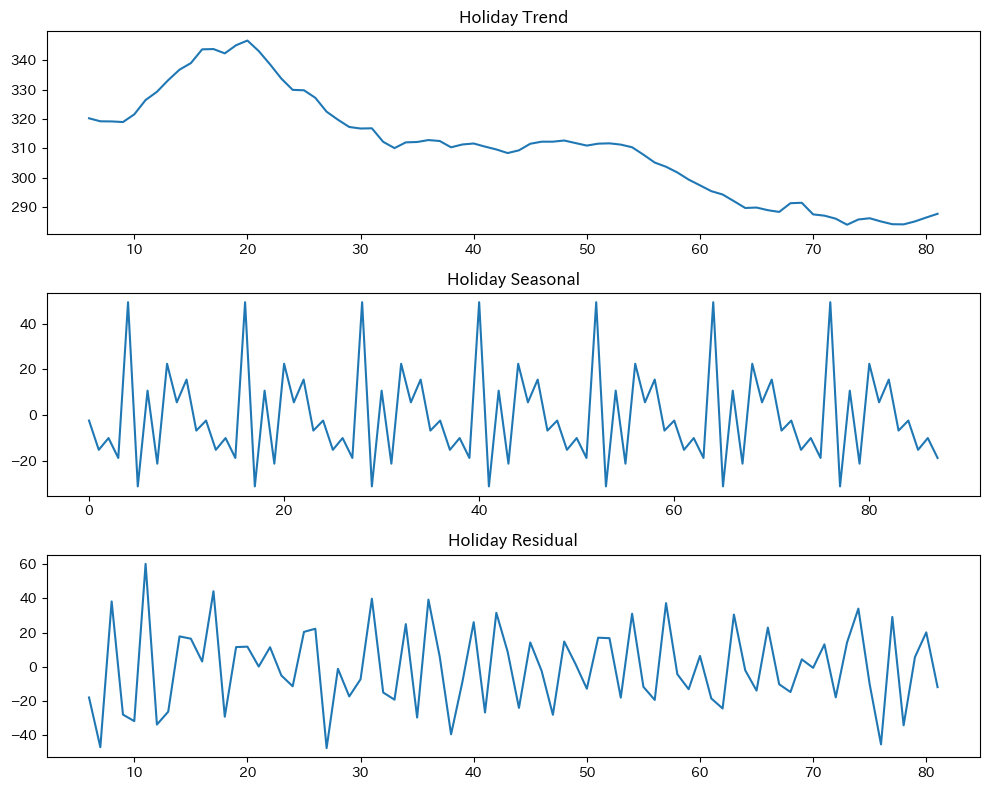

In [309]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 8))

# トレンド成分のプロット
axes[0].plot(holiday_trend)
axes[0].set_title('Holiday Trend')

# 季節成分のプロット
axes[1].plot(holiday_seasonal)
axes[1].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[2].plot(holiday_resid)
axes[2].set_title('Holiday Residual')

plt.tight_layout()
plt.show()



* トレンド成分は平日と同様に、緩やかな減少傾向。減少の度合いは平日よりも小さい、あるいはより安定している可能性がある。
* 間を通して特定の月にピークや谷が見られる。

### 予測結果②

### 北長瀬地域のProphetモデル

In [310]:
#Prophetクラスをインスタンス化
weekday_model = Prophet(seasonality_mode='multiplicative',interval_width=0.7)


#### `kitanagase_weekday_forecast` 平日の場合

In [311]:
#学習期間を2024年4月まで
weekday_model.fit(kitanagase_weekday_df[kitanagase_weekday_df['ds'] <= '2024-04-01'])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [312]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
kitanagase_weekday_future = weekday_model.make_future_dataframe(periods=12, freq='MS')


In [313]:
#予測を実行
kitanagase_weekday_forecast = weekday_model.predict(kitanagase_weekday_future)

#出力された予測値や、不確実性区間を確認
kitanagase_weekday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,598.225954,569.074287,629.461833
1,2018-02-01,552.310875,523.059721,579.816783
2,2018-03-01,647.649234,618.222055,675.856135
3,2018-04-01,611.449682,582.159548,640.903085
4,2018-05-01,581.505044,552.433328,610.724072
...,...,...,...,...
83,2024-12-01,617.252864,589.697720,648.046766
84,2025-01-01,503.089474,473.816751,532.143040
85,2025-02-01,473.998155,445.883501,503.938200
86,2025-03-01,553.990627,521.043392,581.307695


Text(0.5, 1.0, 'Kitanagase Weekday Forecast')

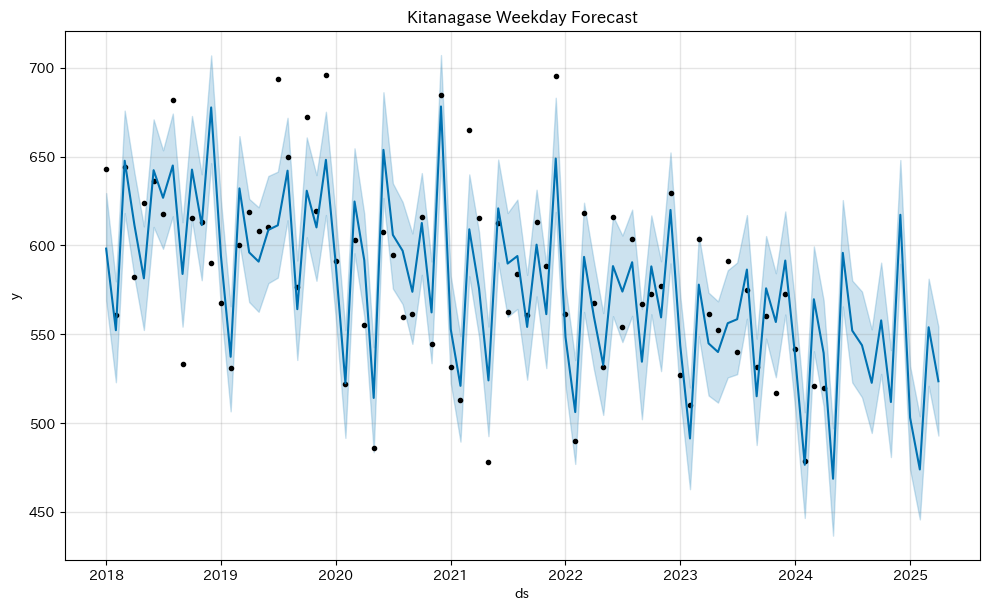

In [314]:
#グラフ上に可視化
fig_forecast = weekday_model.plot(kitanagase_weekday_forecast)
plt.title('Kitanagase Weekday Forecast')


In [315]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = kitanagase_weekday_forecast[(kitanagase_weekday_forecast['ds'] >= start_date) & (kitanagase_weekday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,468.765260,436.736669,497.184403
77,2024-06-01,595.841133,565.717182,625.518173
78,2024-07-01,552.104472,522.927671,580.249971
79,2024-08-01,543.856688,514.576138,574.080865
80,2024-09-01,522.709783,494.506438,552.803577
81,2024-10-01,557.849240,527.737031,590.341104
82,2024-11-01,511.926534,480.954728,541.169093
83,2024-12-01,617.252864,589.697720,648.046766
84,2025-01-01,503.089474,473.816751,532.143040
85,2025-02-01,473.998155,445.883501,503.938200


In [316]:
# 予測の実施（全期間）
kitanagase_weekday_df_future = weekday_model.make_future_dataframe(periods=12,
                                    freq='M')
kitanagase_weekday_df_pred = weekday_model.predict(kitanagase_weekday_df_future)

# 元のデータセットに予測値を結合
kitanagase_weekday_df['Predict'] = kitanagase_weekday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [317]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = kitanagase_weekday_df.iloc[:-12].loc[:, 'Predict']
test_pred = kitanagase_weekday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = kitanagase_weekday_df.iloc[:-12].loc[:, 'y']
y_test = kitanagase_weekday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
30.60326898197185
MAE:
25.257480737425865
MAPE:
0.04711808440459672


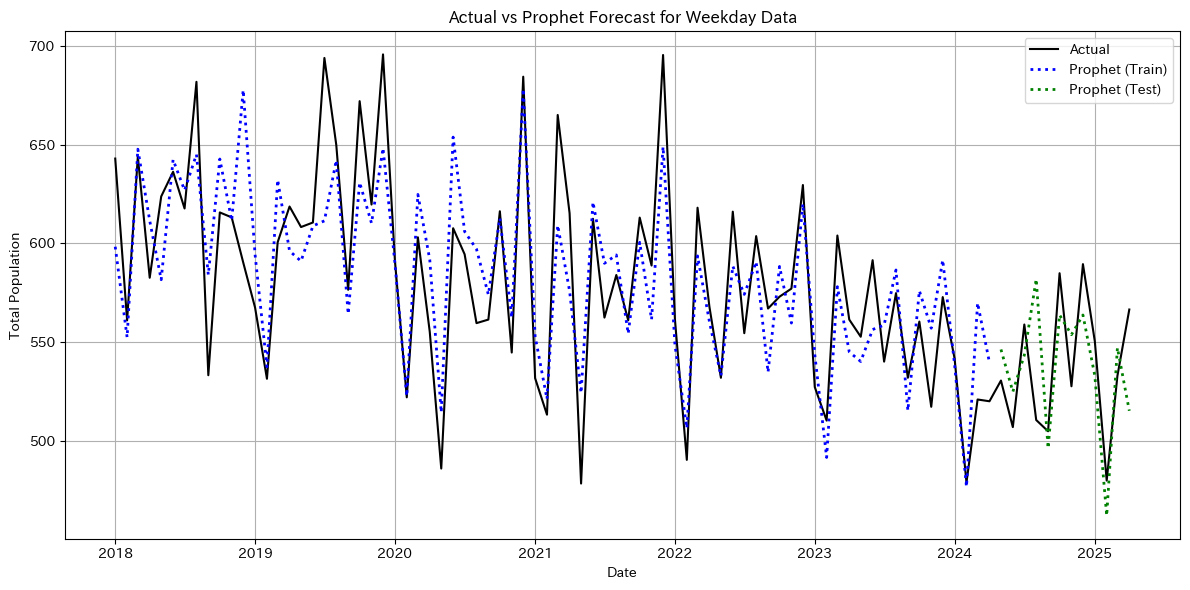

In [318]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(kitanagase_weekday_df['ds'], kitanagase_weekday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(kitanagase_weekday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(kitanagase_weekday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Weekday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 2024年5月から2025年4月までの予測期間では、実際の値と予測値は全体的に似たトレンドを示しており、比較的良好な予測ができている
* 低いRMSE、MAE、そして非常に低いMAPE（5%未満）を示しており、予測精度は高いと評価できる。

#### `kitanagase_holiday_forecast` 休日の場合

In [319]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='multiplicative', interval_width=0.7)

#学習期間を2024年4月まで
holiday_model.fit(kitanagase_holiday_df[kitanagase_holiday_df['ds'] <= '2024-04-01'])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [320]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
kitanagase_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [321]:
#予測を実行
kitanagase_holiday_forecast = holiday_model.predict(kitanagase_holiday_future)

#出力された予測値や、不確実性区間を確認
kitanagase_holiday_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-01-01,343.480624,320.923458,369.437131
1,2018-02-01,310.908011,288.375942,335.797842
2,2018-03-01,324.595364,299.312502,347.597552
3,2018-04-01,324.606794,300.589591,348.730651
4,2018-05-01,384.784961,359.265933,407.707770
...,...,...,...,...
83,2024-12-01,258.176824,234.480852,283.667480
84,2025-01-01,309.814530,286.015761,334.821957
85,2025-02-01,263.536326,239.097337,286.613911
86,2025-03-01,285.830944,260.714660,309.928957


Text(0.5, 1.0, 'Kitanagase Holiday Forecast')

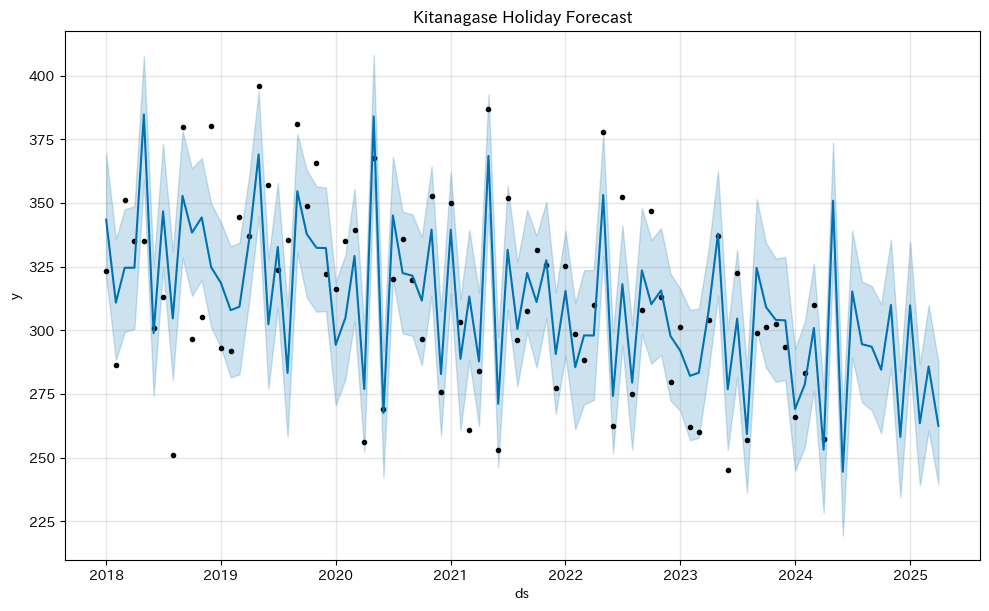

In [322]:
#グラフ上に可視化
fig_forecast = holiday_model.plot(kitanagase_holiday_forecast)
plt.title('Kitanagase Holiday Forecast')


In [323]:
start_date = '2024-05-01'
end_date = '2025-04-01'

filtered_forecast = kitanagase_holiday_forecast[(kitanagase_holiday_forecast['ds'] >= start_date) & (kitanagase_holiday_forecast['ds'] <= end_date)]
display(filtered_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

,ds,yhat,yhat_lower,yhat_upper
76,2024-05-01,350.932760,327.545910,373.851743
77,2024-06-01,244.488190,219.397703,269.088988
78,2024-07-01,315.291318,289.509527,339.246151
79,2024-08-01,294.570441,271.687980,319.163587
80,2024-09-01,293.583426,268.676130,317.417182
81,2024-10-01,284.561755,259.713579,310.257408
82,2024-11-01,309.986313,285.157876,335.597735
83,2024-12-01,258.176824,234.480852,283.667480
84,2025-01-01,309.814530,286.015761,334.821957
85,2025-02-01,263.536326,239.097337,286.613911


In [324]:
# 予測の実施（全期間）
kitanagase_holiday_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
kitanagase_holiday_df_pred = holiday_model.predict(kitanagase_holiday_df_future)
# 元のデータセットに予測値を結合
kitanagase_holiday_df['Predict'] = kitanagase_holiday_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [325]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


#予測値
train_pred = kitanagase_holiday_df.iloc[:-12].loc[:, 'Predict']
test_pred = kitanagase_holiday_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_train = kitanagase_holiday_df.iloc[:-12].loc[:, 'y']
y_test = kitanagase_holiday_df.iloc[-12:].loc[:, 'y']

# 精度指標（テストデータ）
print('RMSE:')
print(np.sqrt(mean_squared_error(y_test, test_pred)))
print('MAE:')
print(mean_absolute_error(y_test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

RMSE:
36.00269060891087
MAE:
29.16595028147917
MAPE:
0.10180100398836062


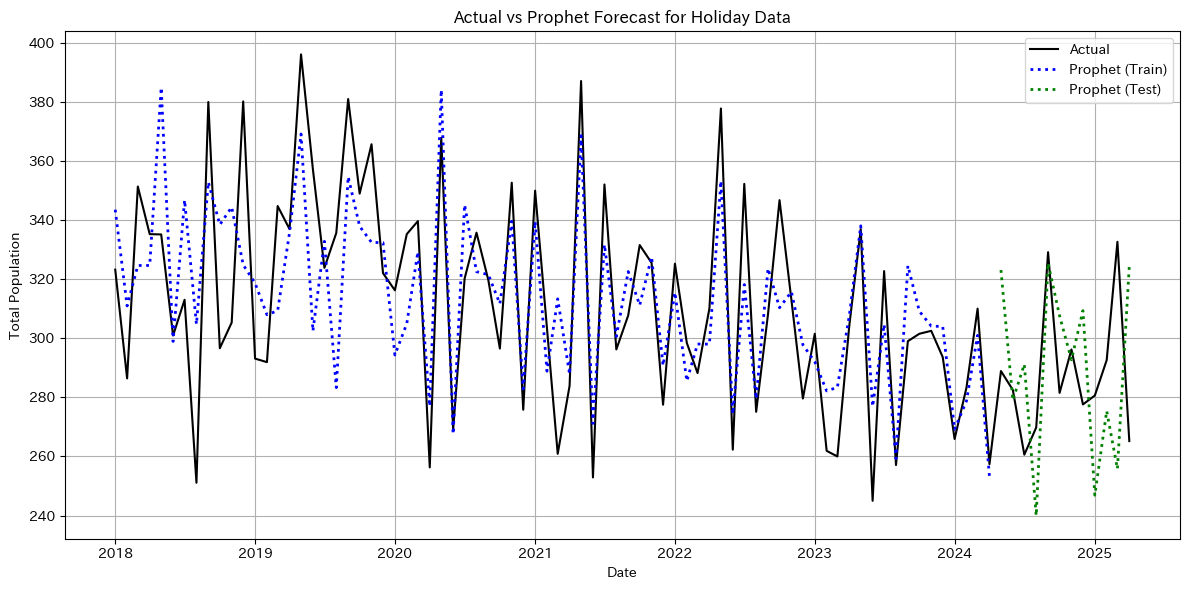

In [326]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(kitanagase_holiday_df['ds'], kitanagase_holiday_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(kitanagase_holiday_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Prophet (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(kitanagase_holiday_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Prophet (Test)")

plt.title('Actual vs Prophet Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* 実際の値と予測値は全体的に似たトレンドを示していますが、一部で乖離が見られます。特に、ピークや谷の時期においては、モデルが実際の変動を過大評価している。
* 予測期間における誤差（RMSEやMAE）は平日データと比較してやや大きめであり、MAPEも10%を超えている。これは、休日の滞在人口が平日よりも変動が大きく、予測が難しい。

# 考察

## STL分解による各地域の結果考察


### 地域ごとのトレンド特性
全ての地域で、平日の人流は休日よりも一貫して高いトレンド値を示している。平日の活動がより活発であることを示した。
* 中心市街地: 他地域と比べて、平日、休日ともに人流の推移が最も高く、主要なハブとしての機能が考えられる。
* 岡南: 平日、休日ともにコロナ禍を経て、緩やかに回復傾向をたどり、近年は安定傾向にある。
* 西大寺: 平日、休日ともにコロナ禍の影響は見受けられるが、近年は安定した推移をしている。
* 浜・原尾島: 他地域同様に、コロナ禍を経て安定した推移の傾向が見られる。
* 北長瀬: 分析期間を通じて平日、休日ともに人流が緩やかな減少傾向を示した。

### 季節パターンの類似性
全ての地域および曜日タイプで、季節パターンは概ね類似していた。人流の年間サイクルに共通性があることを示唆していると考えられる。

## Prophetモデルによる各地域の予測結果の考察

### 中心市街地
*   **平日**: 予測期間（2024年5月以降）においても、実際の値のパターンを概ね踏襲し、モデルは過去のトレンドや季節性をうまく捉えていると考えられる。MAPEは5.66%と比較的良好な精度を示している。
*   **休日**: MAPEは11.15%と平日より誤差が大きく、休日の人流は平日と比較して変動しやすく、予測が難しい可能性が考えられる。特に、パンデミック初期のような大きな変動期には、予測が実績に追従しきれていない乖離が見られる。

### 岡南
*   **平日**: MAPE: 8.03%。比較的安定した人流トレンドに対して、モデルは良好な予測を示していると考えられる。
*   **休日**: MAPE: 13.08%。中心市街地と同様に、休日の方が平日よりも予測誤差が大きくなる傾向が見られ、休日の人流変動の大きさが示唆される。

### 西大寺
*   **平日**: 平日予測（MAPE: 8.63%）は傾向や季節性を捉えているものの、ピークや谷でずれが生じ、変動の振幅に乖離が見らた。
*   **休日**: 休日予測（MAPE: 12.59%）はさらに誤差が大きく、2023年後半の実測値上昇に予測が追いついていない箇所があった。

### 浜・原尾島
*   **平日**: 平日予測（MAPE: 6.67%）が比較的良好な精度を示した。モデルがこの地域の平日人流のパターンを効果的に学習していることがうかがえる。
*   **休日**: 休日予測（MAPE: 11.82%）は平日よりも誤差が大きい。休日人流の予測誤差は平日よりも大きくなる傾向があった。

### 北長瀬
*   **平日**: 平日予測（MAPE: 4.71%）が非常に低く、予測精度が高いと評価できる。
*   **休日**: 実際の値と予測値は全体的に似たトレンドを示していますが、一部で乖離が見られる。特に、ピークや谷の時期においては、モデルが実際の変動を過大評価している傾向があった。

### 全体的なまとめ
Prophetモデルは、各地域の人流データにおける長期的なトレンドと季節性を把握するのに有効であることが示された。しかし、休日の人流データは平日と比較して変動が大きく、予測がやや難しい傾向にある。特に、COVID-19パンデミックのような急激な社会情勢の変化は、モデルの予測精度に影響を与えている可能性がある。今後、予測精度を向上させるためには、外部要因（祝日、イベント、気象データなど）や異常値を考慮したモデルの改善が必要。

# 仮説に対する考察
* 中心部において、他地域と比べても平日の滞在人口が高い水準で推移していた点は、商業・業務機能の集積という都市構造と合致する。
* 岡南地域は、一定量の人流で推移しており、住宅エリアと隣接する郊外型の商業地として日々の生活圏であることがうかがえる。
* 西大寺地域は、地域拠点として比較的一定の人流を維持していた。
* 原・原尾島において、比較的一定の人流を維持しいた。住宅地としての性格が強いことが反映された結果と考える。生活圏としての行動特徴があると考える。
* 北長瀬は再開発による商業施設や公共空間の整備が進んだ地域だが、分析期間内において、大きな変化は見受けられない。平日の予測精度が高い結果を踏まえて、都市機能の充実に伴い、地域内で行動が完結することで、安定した人流結果を導いたと推察する。
